In [1]:
# !pip install librosa tslearn stumpy matplotlib
import os
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesResampler
from tslearn.clustering import TimeSeriesKMeans
from tslearn.shapelets import LearningShapelets
import stumpy # Per Motif e Anomalies

/home/nico/UNIPI/courses/DataMining/venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data = 'dataset/df_fedez_fibra.csv'
index_col = 0
df = pd.read_csv(data, sep=',', index_col=index_col)

pd.set_option('display.max_columns', None)

In [3]:
# Trasforma l'indice in colonna e rinominala
df = df.reset_index().rename(columns={'index': 'track_id'})

In [4]:
AUDIO_COLS = [
    # Audio/Acoustic Features (Using a representative sample)
    'bpm', 'centroid', 'flux', 'rms', 'spectral_complexity', 'pitch', 'flatness', 'duration_ms'
]

## Analyzing similarity from mp3 files

In [5]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.effects
from tslearn.utils import to_time_series_dataset
from tqdm.notebook import tqdm

# Define the base directory where your files are stored
base_dir = os.path.join('dataset', 'fedez_fibra')

# Construct the file path using string formatting
# The format is: directory/id_artist - track_id.mp3
df['file_path'] = df.apply(
    lambda row: os.path.join(base_dir, f"{row['id_artist']} - {row['track_id']}.mp3"), 
    axis=1
)

# Optional: Verify if the files actually exist
# This creates a boolean column 'file_exists'
df['file_exists'] = df['file_path'].apply(os.path.exists)

# Check the first few rows
print(df[['id_artist', 'track_id', 'file_path', 'file_exists']].head())

     id_artist  track_id                                       file_path  \
0  ART25707984  TR434327  dataset/fedez_fibra/ART25707984 - TR434327.mp3   
1  ART25707984  TR443742  dataset/fedez_fibra/ART25707984 - TR443742.mp3   
2  ART25707984  TR252912  dataset/fedez_fibra/ART25707984 - TR252912.mp3   
3  ART25707984  TR316896  dataset/fedez_fibra/ART25707984 - TR316896.mp3   
4  ART25707984  TR466521  dataset/fedez_fibra/ART25707984 - TR466521.mp3   

   file_exists  
0         True  
1         True  
2         True  
3         True  
4         True  


## Use librosa to extract song lenght from audio

In [6]:
# Filter only existing files to avoid errors
df_valid = df[df['file_exists'] == True].copy()

print(f"Checking duration of {len(df_valid)} tracks...")

durations = []
# Loop through paths (tqdm shows a progress bar)
for path in tqdm(df_valid['file_path']):
    try:
        # librosa.get_duration is much faster than librosa.load
        # it reads metadata instead of decoding the whole audio
        d = librosa.get_duration(path=path)
        durations.append(d)
    except Exception as e:
        print(f"Error reading {path}: {e}")
        durations.append(None)

df_valid['duration_sec'] = durations

# Drop any failed reads
df_valid = df_valid.dropna(subset=['duration_sec'])

print("\n--- ✅ Duration Check Complete ---")
print(df_valid[['id_artist', 'duration_sec']].head())

Checking duration of 454 tracks...


  0%|          | 0/454 [00:00<?, ?it/s]


--- ✅ Duration Check Complete ---
     id_artist  duration_sec
0  ART25707984    265.729167
1  ART25707984    259.666667
2  ART25707984    219.986667
3  ART25707984    304.320979
4  ART25707984    215.146667


Mean:   214.26 s
Median: 205.82 s
Min:    28.52 s
Max:    672.01 s


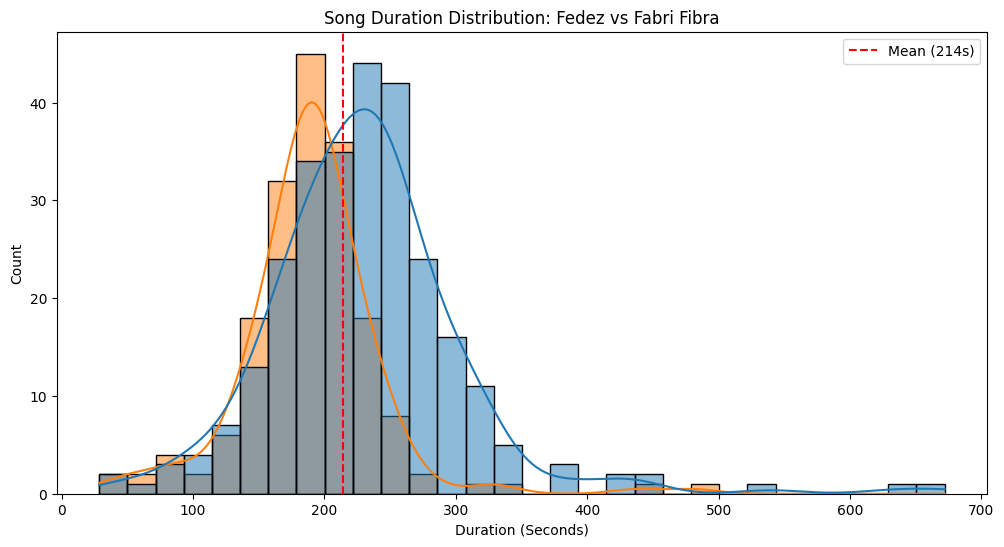

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
mean_dur = df_valid['duration_sec'].mean()
median_dur = df_valid['duration_sec'].median()
min_dur = df_valid['duration_sec'].min()
max_dur = df_valid['duration_sec'].max()

print(f"Mean:   {mean_dur:.2f} s")
print(f"Median: {median_dur:.2f} s")
print(f"Min:    {min_dur:.2f} s")
print(f"Max:    {max_dur:.2f} s")

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(data=df_valid, x='duration_sec', hue='id_artist', kde=True, bins=30, alpha=0.5)
plt.axvline(mean_dur, color='red', linestyle='--', label=f'Mean ({mean_dur:.0f}s)')
plt.title('Song Duration Distribution: Fedez vs Fabri Fibra')
plt.xlabel('Duration (Seconds)')
plt.legend()
plt.show()

## Check on outliers and remove duplicates

In [42]:
print(df_valid[df_valid['duration_sec'] < 60] [['track_id', 'duration_sec', 'title']])

print(df_valid[df_valid['duration_sec'] > 8*60] [['track_id', 'duration_sec', 'title']])

# Possibly dropp the 2 intro since they are not songs.
# Possibly drop long songs due to fixed resampling

# 1. Create a list of the specific IDs you want to remove
# Replace these strings with the actual IDs from your print output
# 1. (Optional) Remove specific IDs first if they are long/corrupt
ids_to_remove = ['TR408042', 'TR246352', 'TR512155', 'TR267048', 'TR300576', 'TR420459']
df_valid = df_valid[~df_valid['track_id'].isin(ids_to_remove)].copy()

# 2. Drop ALL tracks below 60 seconds automatically
df_valid = df_valid[df_valid['duration_sec'] >= 60].copy()

# 3. Verify
print(f"Removed specific IDs and all tracks < 60s.")
print(f"Remaining songs: {len(df_valid)}")

Empty DataFrame
Columns: [track_id, duration_sec, title]
Index: []
     track_id  duration_sec                title
10   TR589489    672.008708  Niente Di Personale
21   TR239743    633.765458       Fatti Da Parte
139  TR983233    539.980063    Idee Stupide 2016
421  TR414330    480.339604             BANCOMAT
Removed specific IDs and all tracks < 60s.
Remaining songs: 443


In [43]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from tslearn.preprocessing import TimeSeriesResampler, TimeSeriesScalerMeanVariance

def load_audio(path: str, sr: int = 22050, mono: bool = True, top_db: int = 25):
    """Carica l'audio, esegue il resample, converte in mono e rimuove i silenzi."""
    try:
        # Caricamento
        y, sr_out = librosa.load(path, sr=sr, mono=mono)
        
        if y is None or y.size == 0:
            return None, sr
        
        # Conversione in float32 per risparmiare memoria
        y = y.astype(np.float32, copy=False)

        # Trim del silenzio (rimuove l'inizio e la fine "vuoti")
        y, _ = librosa.effects.trim(y, top_db=top_db)
        
        if y.size == 0:
            return None, sr
            
        return y, sr_out
    except Exception:
        return None, sr

def extract_features_fast(y: np.ndarray, sr: int, hop_length: int = 512, n_fft: int = 2048, n_mfcc: int = 20, min_frames: int = 50):
    """Estrae i coefficienti MFCC e restituisce uno shape (T, n_mfcc)."""
    if y is None or len(y) < hop_length * 2:
        return None

    # Estrazione MFCC
    mfcc = librosa.feature.mfcc(
        y=y, 
        sr=sr, 
        n_mfcc=n_mfcc, 
        hop_length=hop_length, 
        n_fft=n_fft
    ) 

    # mfcc è (n_mfcc, T), noi vogliamo (T, n_mfcc) per tslearn
    T = mfcc.shape[1]
    if T < min_frames:
        return None

    return mfcc.T.astype(np.float32, copy=False)

def extract_extra_features_fast(y: np.ndarray, sr: int, hop_length: int = 512, n_fft: int = 2048, n_mfcc: int = 20, min_frames: int = 50):
    
    if y is None or len(y) < hop_length * 2:
        return None

    # 1. MFCC (Timbro Vocale)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=n_fft) 
    
    # 2. Delta (Velocità del Flow)
    mfcc_delta = librosa.feature.delta(mfcc)

    # 3. Delta-Delta (Accelerazione/Ritmo)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # 4. Spectral Centroid (Brillantezza - Fedez vs Fibra scuro)
    # Restituisce (1, T), quindi dobbiamo fare un po' di attenzione alle dimensioni
    # centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop_length, n_fft=n_fft)
    
    # Normalizziamo il centroide (spesso ha valori enormi tipo 3000, gli MFCC sono tipo 10-100)
    # Una normalizzazione grezza logaritmica aiuta a metterlo sulla stessa scala
    # centroid = np.log1p(centroid)

    # 5. Mettiamo tutto insieme
    # Stack verticale: 20 + 20 + 20 + 1 = 61 Features totali
    combined_features = np.vstack([mfcc, mfcc_delta, mfcc_delta2])  # , centroid])

    # Controllo lunghezza
    T = combined_features.shape[1]
    if T < min_frames:
        return None

    # Transpose per avere (Tempo, Features)
    return combined_features.T.astype(np.float32, copy=False)

In [57]:
# 1. Filtriamo solo i file esistenti dal tuo df originale
df_ff = df_valid[df_valid['file_exists'] == True].copy()
paths = df_ff["file_path"].tolist()

X_raw = []
indices_ok = [] # Teniamo traccia di quali righe di df_ff sono valide

print(f"Inizio elaborazione di {len(paths)} tracce...")
for idx, p in tqdm(enumerate(paths), total=len(paths)):
    sig, sr = load_audio(p)
    features = extract_extra_features_fast(sig, sr)
    
    if features is not None:
        X_raw.append(features)
        indices_ok.append(idx)

# 2. Creiamo il DataFrame finale con TUTTE le tue colonne originali
# Filtriamo df_ff usando gli indici dei file che hanno superato il processing audio
df_processed = df_ff.iloc[indices_ok].copy()

# 3. Resampling e Scaling (L=1200)
L = 1200
print(f"Resampling e Scaling (Target L={L})...")
X = TimeSeriesResampler(sz=L).fit_transform(X_raw)
X = TimeSeriesScalerMeanVariance().fit_transform(X)

# 4. Salvataggio su disco
output_dir = "processed_audio_data"
os.makedirs(output_dir, exist_ok=True)

# Salviamo la matrice X (pesante)
np.save(os.path.join(output_dir, "X_features.npy"), X.astype(np.float32))

# Salviamo il DataFrame con tutte le 50+ colonne (leggero)
df_processed.to_csv(os.path.join(output_dir, "df_processed.csv"), index=False)

print("\n--- DONE ---")
print(f"X shape: {X.shape}")                
print(f"Dati in df_processed: {len(df_processed)}")

Inizio elaborazione di 443 tracce...


  0%|          | 0/443 [00:00<?, ?it/s]

Resampling e Scaling (Target L=1200)...

--- DONE ---
X shape: (443, 1200, 60)
Dati in df_processed: 443


# RUNNARE QUESTO PER MINUTO CENTRALE DI CANZONI

In [ ]:
import numpy as np
import librosa

def load_center_minute_fixed(path, target_sr=22050, segment_duration=60):
    """
    Carica 60s dal centro. Se il file è corto, aggiunge silenzio (padding).
    Restituisce SEMPRE un array della stessa lunghezza esatta.
    """
    # Calcoliamo quanti sample esatti ci servono (es. 22050 * 60 = 1,323,000)
    target_samples = int(target_sr * segment_duration)
    
    try:
        duration = librosa.get_duration(path=path)
        
        # --- CASO A: Il file è più lungo di 60s ---
        if duration > segment_duration:
            start = (duration / 2) - (segment_duration / 2)
            sig, sr = librosa.load(path, sr=target_sr, offset=start, duration=segment_duration)
            
            # A volte librosa carica qualche sample in più o in meno per arrotondamenti
            # Tagliamo l'eccedenza o aggiustiamo
            if len(sig) > target_samples:
                sig = sig[:target_samples]
            elif len(sig) < target_samples:
                # Piccolissimo pad se mancano pochi sample per arrotondamento
                pad_width = target_samples - len(sig)
                sig = np.pad(sig, (0, pad_width), mode='constant')
                
        # --- CASO B: Il file è più corto di 60s ---
        else:
            # Carichiamo tutto il file
            sig, sr = librosa.load(path, sr=target_sr)
            
            # Calcoliamo quanto silenzio aggiungere
            pad_width = target_samples - len(sig)
            
            # Applichiamo il padding (aggiungiamo zeri alla fine)
            if pad_width > 0:
                sig = np.pad(sig, (0, pad_width), mode='constant')
                
        return sig, sr

    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None, None

# --- ESECUZIONE ---
X_raw = []
indices_ok = []
df_ff = df_valid[df_valid['file_exists'] == True].copy()
paths = df_ff["file_path"].tolist()


print(f"Inizio elaborazione con Padding a {60}s...")

for idx, p in tqdm(enumerate(paths), total=len(paths)):
    # Usiamo la nuova funzione 'fixed'
    sig, sr = load_center_minute_fixed(p, segment_duration=60)
    
    if sig is None:
        continue

    hop_length = 2048

    features = extract_extra_features_fast(sig, sr, hop_length=hop_length, n_fft=hop_length)
    
    if features is not None:
        X_raw.append(features)
        indices_ok.append(idx)

# --- SALVATAGGIO ---
output_dir = "processed_audio_data"
os.makedirs(output_dir, exist_ok=True)

# 1. Convertiamo in array (ora è sicuro perché tutti i file hanno la stessa lunghezza!)
X_final = np.array(X_raw)

print(f"Shape finale: {X_final.shape}") # Ora non darà errore

# 2. Salvataggio
np.save(os.path.join(output_dir, "X_features_one_minute.npy"), X_final.astype(np.float32))

# 3. Filtriamo e salviamo il DF
df_processed = df_ff.iloc[indices_ok].copy()
df_processed.to_csv(os.path.join(output_dir, "df_processed_1_minute.csv"), index=False)

Inizio elaborazione con Padding a 60s...


  0%|          | 0/443 [00:00<?, ?it/s]

Shape finale: (443, 646, 60)


## RUN FOR 1 minute X

In [9]:
import numpy as np
import pandas as pd
import os

output_dir = "processed_audio_data"

# 1. Carica la matrice (veloce)
X = np.load("processed_audio_data/X_features_one_minute.npy")
# Rimuoviamo l'ultima feature (indice -1)
X = X[:, :, :13]

df_processed = pd.read_csv(os.path.join(output_dir, "df_processed_1_minute.csv"))
# 2. Prendi y_ok direttamente dal tuo df_processed (risolve il NameError)
y_ok = df_processed['id_artist'].values

print(f"Dati pronti! X shape: {X.shape}, y_ok: {len(y_ok)}")
# Ora puoi eseguire direttamente la cella del clustering (K-Means)

Dati pronti! X shape: (443, 646, 13), y_ok: 443


## RUN FOR RESAMPLED X

In [58]:
import numpy as np
import pandas as pd
import os

output_dir = "processed_audio_data"

# 1. Carica la matrice (veloce)
X_resampled = np.load("processed_audio_data/X_features.npy")
# Rimuoviamo l'ultima feature (indice -1)
X_resampled = X_resampled[:, :, :13]

df_processed_resampled = pd.read_csv(os.path.join(output_dir, "df_processed.csv"))
# 2. Prendi y_ok direttamente dal tuo df_processed (risolve il NameError)
y_ok = df_processed_resampled['id_artist'].values

print(f"Dati pronti! X_resampled shape: {X_resampled.shape}, y_ok: {len(y_ok)}")
# Ora puoi eseguire direttamente la cella del clustering (K-Means)

Dati pronti! X_resampled shape: (443, 1200, 13), y_ok: 443


## Unsupervised clustering

In [82]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
scaler = TimeSeriesScalerMeanVariance(mu=0, std=1)
X_scaled = scaler.fit_transform(X)

scaler = TimeSeriesScalerMeanVariance(mu=0, std=1)
X_scaled_resampled = scaler.fit_transform(X_resampled)

In [83]:

from tslearn.preprocessing import TimeSeriesResampler

# 1. Definiamo la nuova lunghezza "agile"
L_FAST = 200 

print(f"Riduzione risoluzione: da {X_resampled.shape[1]} a {L_FAST} punti...")

# 2. Resampling della matrice X già esistente
# X ha forma (454, 1200, 20) -> diventerà (454, 300, 20)
X_clustering_resampled = TimeSeriesResampler(sz=L_FAST).fit_transform(X_scaled_resampled)
X_clustering_scaled_resampled = scaler.fit_transform(X_clustering_resampled)

print(f"Nuova shape per clustering: {X_clustering_scaled_resampled.shape}")

# ORA usa X_clustering nel loop di TimeSeriesKMeans che abbiamo visto prima

Riduzione risoluzione: da 1200 a 200 punti...
Nuova shape per clustering: (443, 200, 13)


### DTW

Inizio Clustering DTW Ultra-Rapido...


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=2 | Inertia: 7486.66 | Tempo: 466.2s


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=3 | Inertia: 7402.81 | Tempo: 394.3s


d:\Anaconda\envs\mining_env\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


k=4 | Inertia: 7388.03 | Tempo: 297.2s


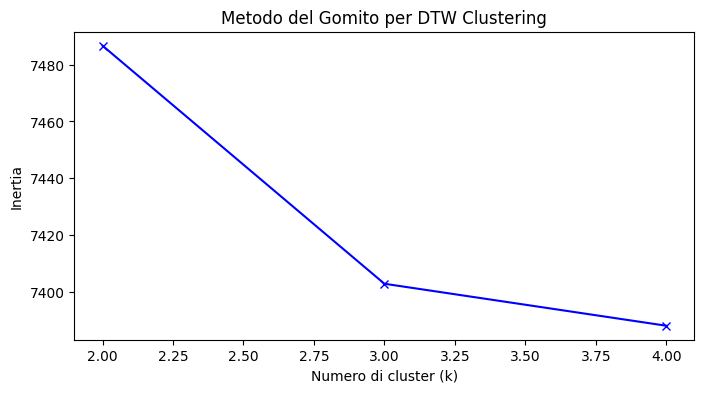

In [ ]:
from tslearn.clustering import TimeSeriesKMeans
import numpy as np
import time
import matplotlib.pyplot as plt

# ---- 1. Parametri Light ----
max_iter = 5 
n_init = 1
k_values = [2, 3, 4] 

results_inertia = []
models = {}

print("Inizio Clustering DTW Ultra-Rapido...")

# ---- 2. Loop di Clustering ----
for k in k_values:
    start_time = time.time()
    
    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        metric_params={"sakoe_chiba_radius": 0.05},
        max_iter=max_iter,
        n_init=n_init,
        random_state=42,
        n_jobs=-1 # Usa tutti i core della CPU
    )

    labels = km.fit_predict(X_clustering_scaled)
    duration = time.time() - start_time
    
    # L'Inertia è già calcolata dal modello alla fine di fit_predict
    inertia = km.inertia_
    results_inertia.append(inertia)
    models[k] = labels

    print(f"k={k} | Inertia: {inertia:.2f} | Tempo: {duration:.1f}s")

# ---- 3. Visualizzazione "Gomito" (Elbow Method) ----
plt.figure(figsize=(8, 4))
plt.plot(k_values, results_inertia, 'bx-')
plt.xlabel('Numero di cluster (k)')
plt.ylabel('Inertia')
plt.title('Metodo del Gomito per DTW Clustering')
plt.show()

In [ ]:
# Scegli il k basandoti sul grafico del gomito
k_scelto = 3

# Recuperiamo le etichette salvate senza ricalcolare nulla
cl_dtw = models[k_scelto]

print(f"Risultati estratti per k={k_scelto}")
print(f"Distribuzione campioni nei cluster: {np.bincount(cl_dtw)}")

Risultati estratti per k=3
Distribuzione campioni nei cluster: [164 110 174]


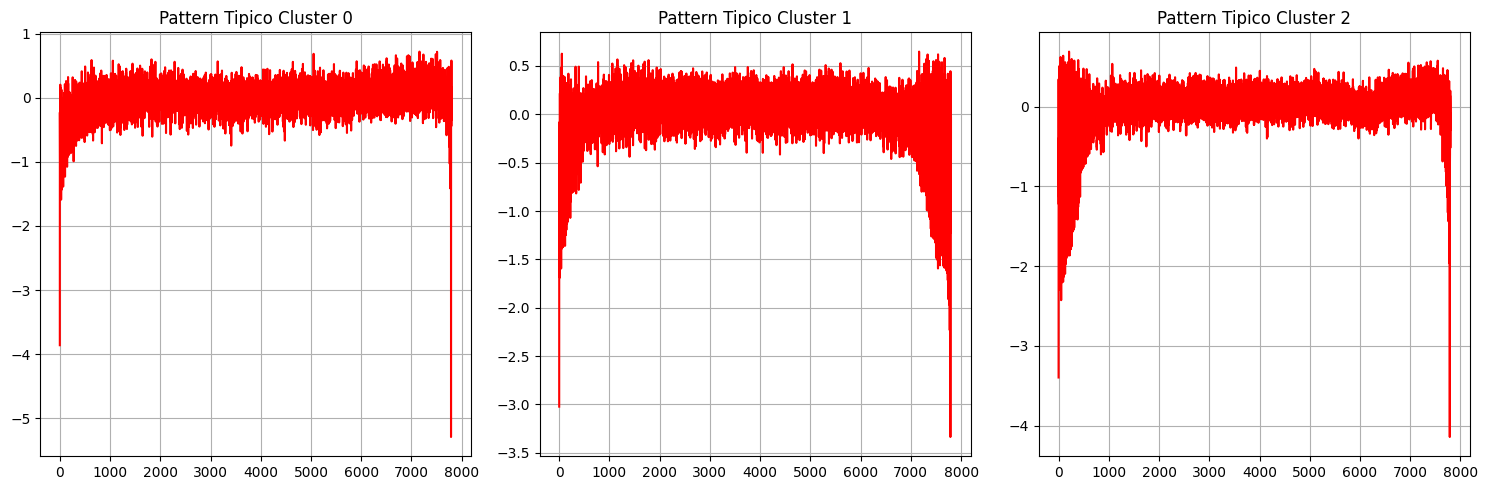

In [ ]:
import matplotlib.pyplot as plt

# Recuperiamo il modello KMeans specifico per il k scelto
# Nota: dovremmo aver salvato l'oggetto modello nel loop precedente
# Aggiorna il loop precedente aggiungendo: models_obj[k] = km

plt.figure(figsize=(15, 5))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    # Prendiamo il centroide (il "pattern tipo") del cluster i
    # km_dtw_final deve essere il modello fittato con k_scelto
    centroid = km.cluster_centers_[i] 
    plt.plot(centroid.ravel(), "r-")
    plt.title(f"Pattern Tipico Cluster {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()

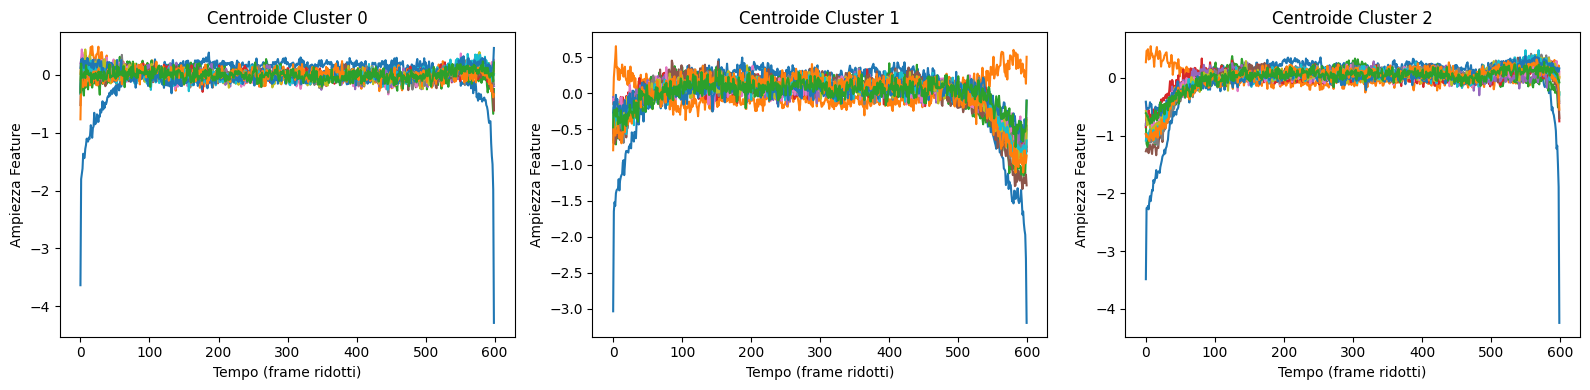

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    
    # Estraiamo i dati del cluster i (usando X_fast che è quello del clustering)
    cluster_data = X_clustering_scaled[cl_dtw == i]
    
    # Calcoliamo il centroide medio per questo cluster
    centroid = cluster_data.mean(axis=0)
    
    plt.plot(centroid)
    plt.title(f"Centroide Cluster {i}")
    plt.xlabel("Tempo (frame ridotti)")
    plt.ylabel("Ampiezza Feature")

plt.tight_layout()
plt.show()

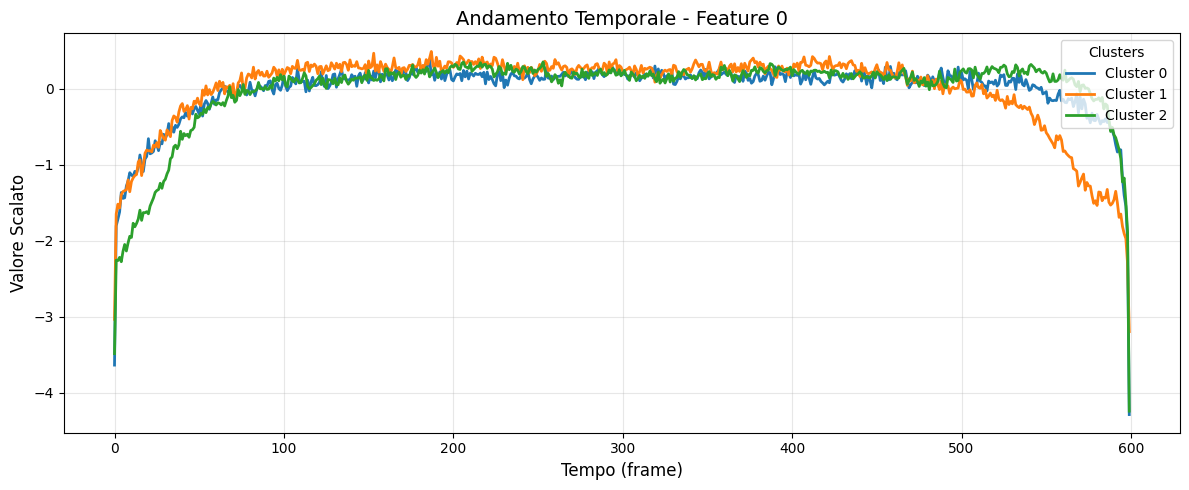

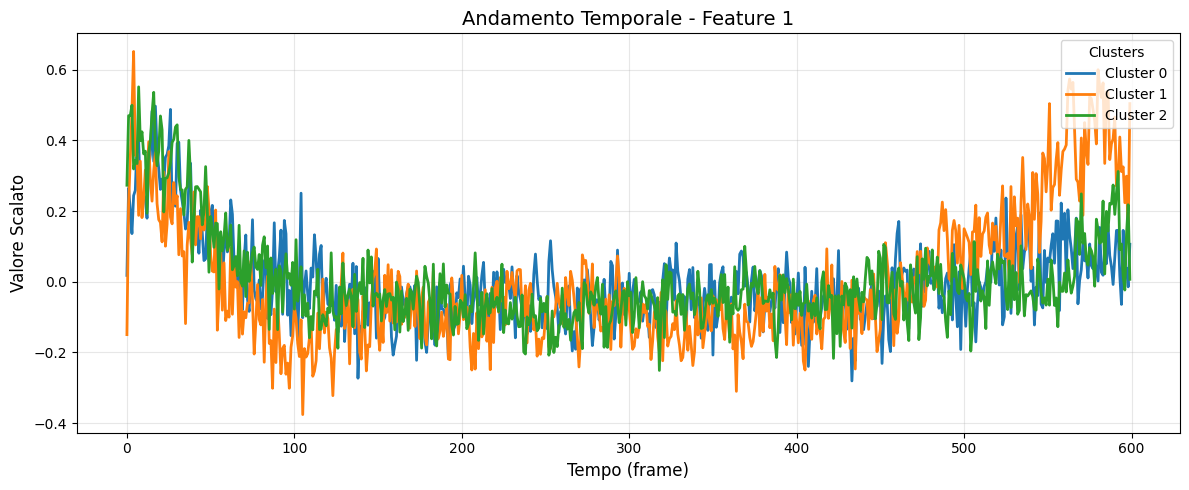

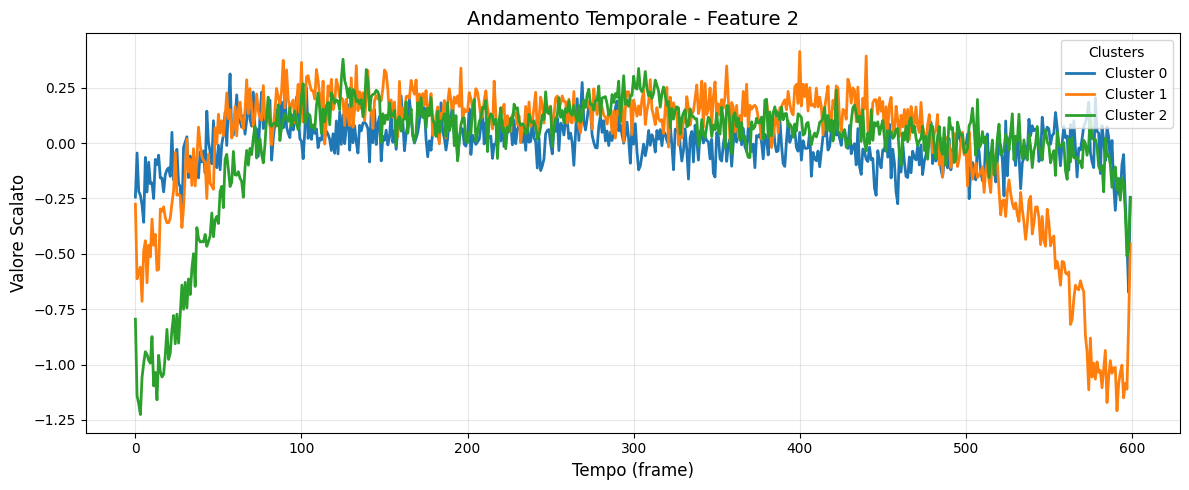

In [ ]:
import matplotlib.pyplot as plt

feature_indices = [0, 1, 2]  # Le feature che vuoi analizzare
k_scelto = len(np.unique(cl_dtw)) # Recupera il numero di cluster

for j in feature_indices:
    # Creiamo una nuova figura per ogni feature
    plt.figure(figsize=(12, 5))
    
    # Iteriamo su ogni cluster
    for i in range(k_scelto):
        # Estraiamo i dati del cluster i
        cluster_data = X_clustering_scaled[cl_dtw == i]
        
        if len(cluster_data) > 0:
            # Calcoliamo il centroide (media dei brani nel cluster)
            # cluster_data è (n_brani, tempo, feature) -> mean(axis=0) è (tempo, feature)
            centroid = cluster_data.mean(axis=0)
            
            # Selezioniamo SOLO la feature j corrente
            plt.plot(centroid[:, j], label=f"Cluster {i}", linewidth=2)

    # Personalizzazione del grafico della feature j
    plt.title(f"Andamento Temporale - Feature {j}", fontsize=14)
    plt.xlabel("Tempo (frame)", fontsize=12)
    plt.ylabel("Valore Scalato", fontsize=12)
    plt.legend(loc='upper right', title="Clusters")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show() # Mostra il grafico della feature j prima di passare alla prossima

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo una copia per l'analisi: df_processed resta pulito
df_analysis = df_processed.copy()
df_analysis['cluster'] = cl_dtw  # Aggiungiamo i cluster solo alla copia

# 1. PCA: Appiattiamo X_clustering (454, 150, 20) -> (454, 3000)
X_flat = X_clustering_scaled_resampled.reshape(X_clustering_scaled_resampled.shape[0], -1)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

# Aggiungiamo le coordinate PCA alla copia per il plotting
df_analysis['pca_1'] = X_pca[:, 0]
df_analysis['pca_2'] = X_pca[:, 1]

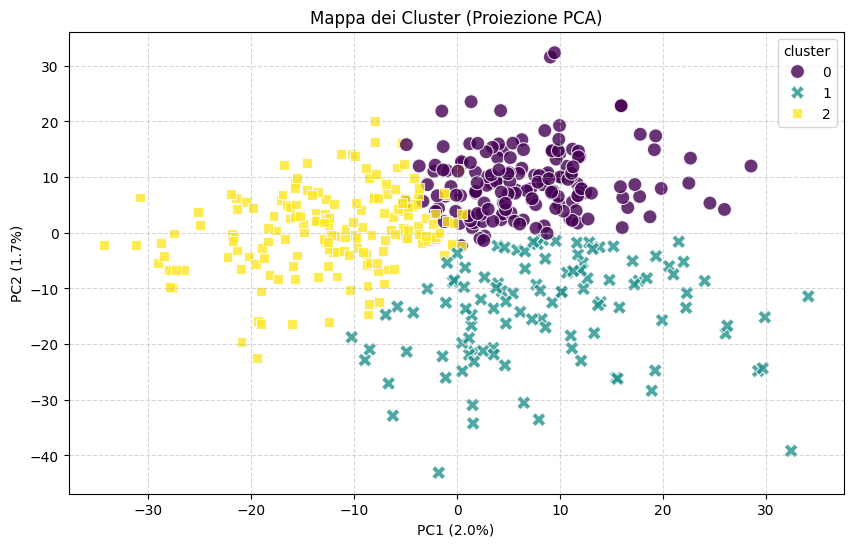

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analysis, 
    x='pca_1', y='pca_2', 
    hue='cluster', 
    palette='viridis',
    style='cluster',
    s=100, alpha=0.8
)
plt.title("Mappa dei Cluster (Proiezione PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

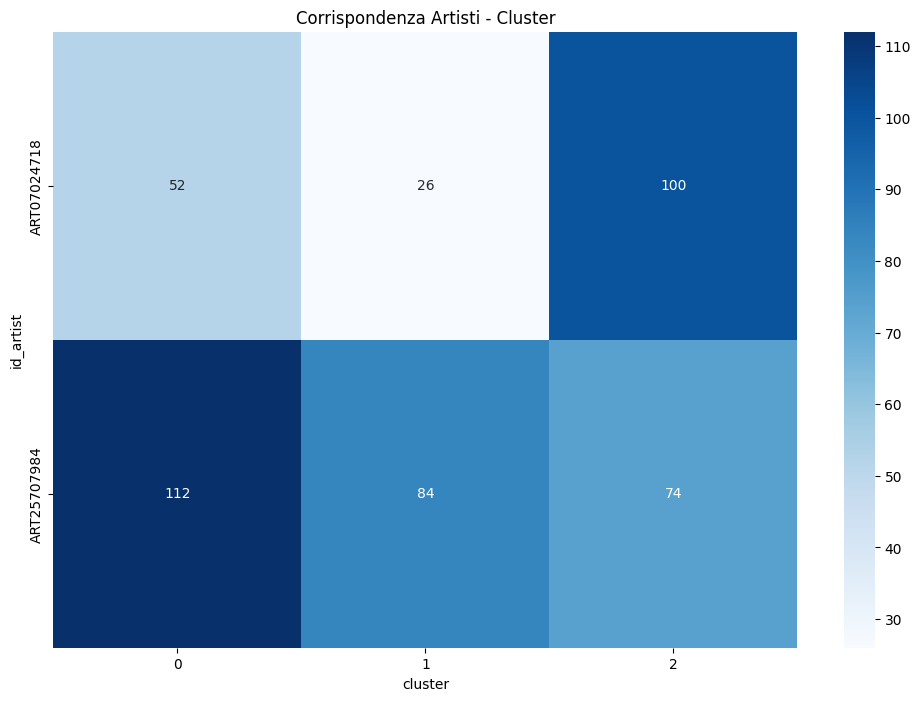

Cluster 0: L'artista più presente è 'ART25707984' (112 brani).
Cluster 1: L'artista più presente è 'ART25707984' (84 brani).
Cluster 2: L'artista più presente è 'ART07024718' (100 brani).


In [ ]:
# Creiamo la tabella di contingenza (Artisti vs Cluster)
artist_ctab = pd.crosstab(df_analysis['id_artist'], df_analysis['cluster'])

# Visualizzazione con Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(artist_ctab, annot=True, fmt='d', cmap="Blues")
plt.title("Corrispondenza Artisti - Cluster")
plt.show()

# Identifichiamo l'artista "simbolo" di ogni cluster
for c in sorted(df_analysis['cluster'].unique()):
    top_art = artist_ctab[c].idxmax()
    count = artist_ctab[c].max()
    print(f"Cluster {c}: L'artista più presente è '{top_art}' ({count} brani).")

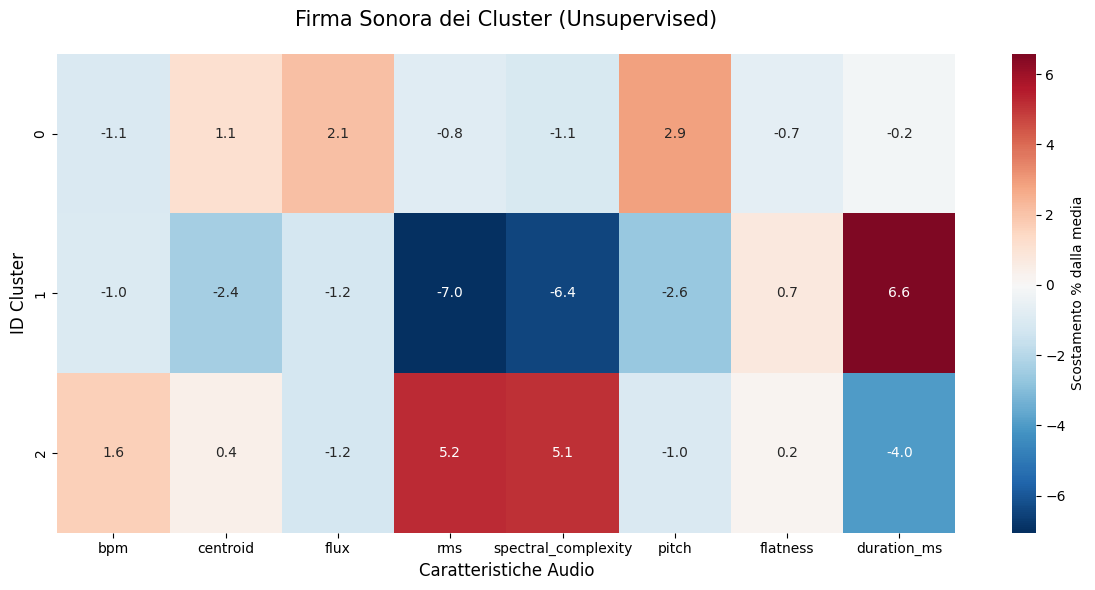

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepariamo i dati (usando la copia per non sporcare df_processed)
df_analysis = df_processed.copy()
df_analysis['Cluster'] = cl_dtw

# 2. Calcoliamo lo scostamento percentuale rispetto alla media globale
cluster_means = df_analysis.groupby('Cluster')[AUDIO_COLS].mean()
global_means = df_analysis[AUDIO_COLS].mean()
relative_diff = (cluster_means / global_means - 1) * 100

# 3. Creazione della Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    relative_diff, 
    annot=True,              # Mostra i numeri dentro le celle
    fmt=".1f",               # Un decimale
    cmap="RdBu_r",           # Blu per valori bassi, Rosso per alti, Bianco per la media
    center=0,                # Il bianco rappresenta lo 0 (la media globale)
    cbar_kws={'label': 'Scostamento % dalla media'}
)

plt.title("Firma Sonora dei Cluster (Unsupervised)", fontsize=15, pad=20)
plt.ylabel("ID Cluster", fontsize=12)
plt.xlabel("Caratteristiche Audio", fontsize=12)
plt.tight_layout()
plt.show()

## Euclidian

Inizio Clustering (Euclidean) con valutazione Silhouette...
k=2 | Inertia: 2474.58 | Silhouette: 0.012 | Tempo: 5.2s
k=3 | Inertia: 2446.67 | Silhouette: 0.010 | Tempo: 6.0s
k=4 | Inertia: 2443.25 | Silhouette: 0.004 | Tempo: 5.9s
k=5 | Inertia: 2434.24 | Silhouette: 0.004 | Tempo: 5.5s
k=6 | Inertia: 2420.44 | Silhouette: 0.006 | Tempo: 5.7s
k=7 | Inertia: 2418.70 | Silhouette: 0.005 | Tempo: 5.3s


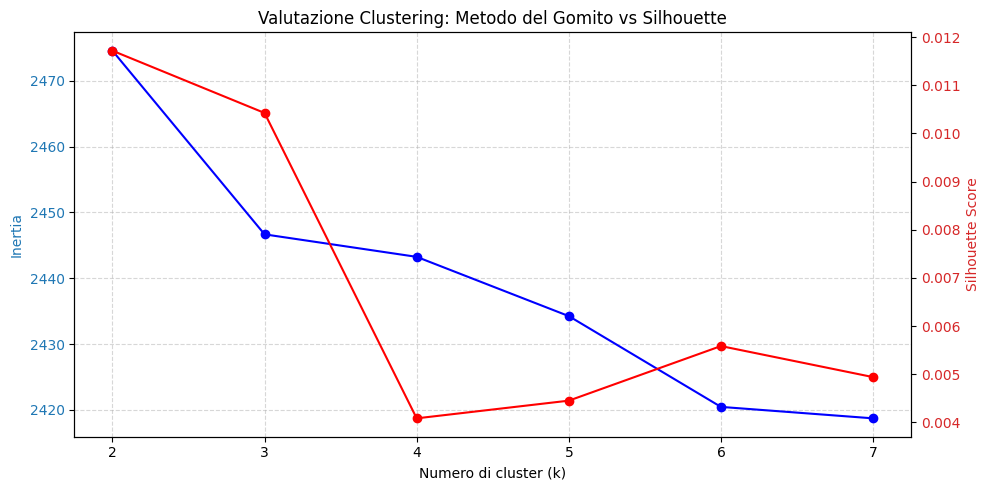

In [84]:
from tslearn.clustering import TimeSeriesKMeans, silhouette_score
import numpy as np
import time
import matplotlib.pyplot as plt

# ---- 1. Parametri ----
max_iter = 10 # Aumentato leggermente per stabilità
n_init = 2    # Aumentato per evitare minimi locali "sfortunati"
k_values = [2, 3, 4, 5, 6, 7] 

results_inertia = []
results_silhouette = []
models = {}

print("Inizio Clustering (Euclidean) con valutazione Silhouette...")

# ---- 2. Loop di Clustering ----
for k in k_values:
    start_time = time.time()
    
    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="euclidean", 
        max_iter=max_iter,
        n_init=n_init,
        random_state=42,
        n_jobs=-1
    ) 

    labels = km.fit_predict(X_clustering_scaled_resampled)
    duration = time.time() - start_time
    
    # Metrica 1: Inertia
    inertia = km.inertia_
    results_inertia.append(inertia)
    
    # Metrica 2: Silhouette Score
    # Nota: usiamo X_clustering appiattito per silhouette_score standard se Euclidean
    # oppure silhouette_score di tslearn per coerenza
    score = silhouette_score(X_clustering_scaled_resampled, labels, metric="euclidean")
    results_silhouette.append(score)
    
    models[k] = labels
    print(f"k={k} | Inertia: {inertia:.2f} | Silhouette: {score:.3f} | Tempo: {duration:.1f}s")

# ---- 3. Doppia Visualizzazione ----
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia (Gomito)
color = 'tab:blue'
ax1.set_xlabel('Numero di cluster (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(k_values, results_inertia, 'bo-', label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot Silhouette (Picco)
ax2 = ax1.twinx() 
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_values, results_silhouette, 'ro-', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Valutazione Clustering: Metodo del Gomito vs Silhouette')
fig.tight_layout()
plt.show()

In [86]:
# Scegli il k basandoti sul grafico del gomito
k_scelto = 3

# Recuperiamo le etichette salvate senza ricalcolare nulla
cl_eu_unsup = models[k_scelto]

print(f"Risultati estratti per k={k_scelto}")
print(f"Distribuzione campioni nei cluster: {np.bincount(cl_eu_unsup)}")

Risultati estratti per k=3
Distribuzione campioni nei cluster: [173 102 168]


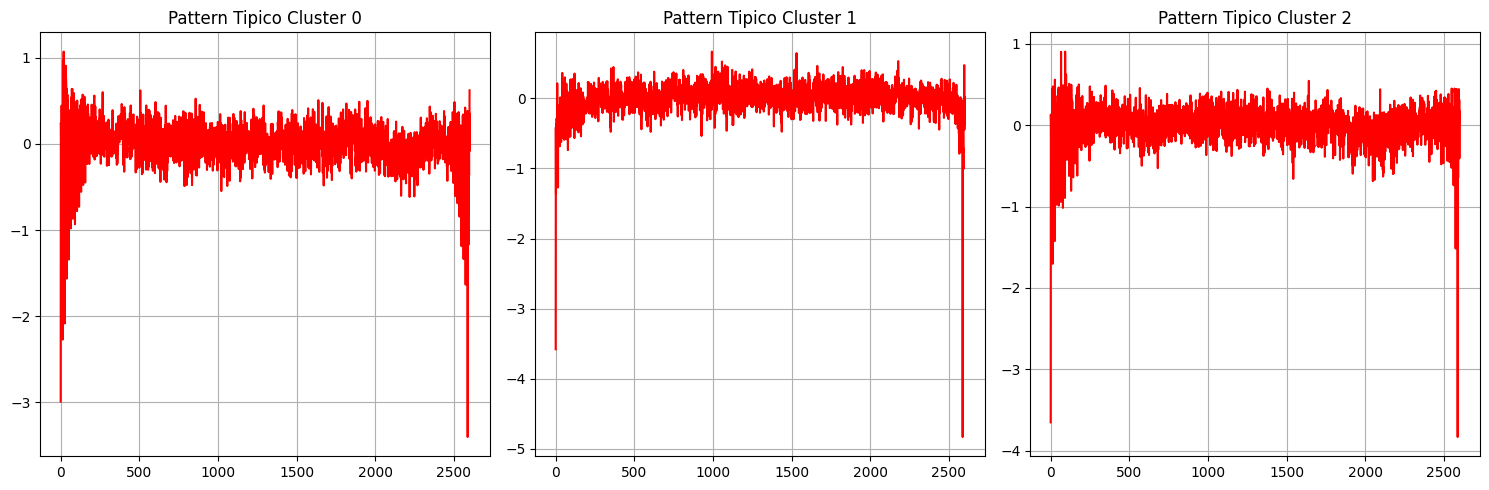

In [87]:
import matplotlib.pyplot as plt

# Recuperiamo il modello KMeans specifico per il k scelto
# Nota: dovremmo aver salvato l'oggetto modello nel loop precedente
# Aggiorna il loop precedente aggiungendo: models_obj[k] = km

plt.figure(figsize=(15, 5))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    # Prendiamo il centroide (il "pattern tipo") del cluster i
    # km_dtw_final deve essere il modello fittato con k_scelto
    centroid = km.cluster_centers_[i] 
    plt.plot(centroid.ravel(), "r-")
    plt.title(f"Pattern Tipico Cluster {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()

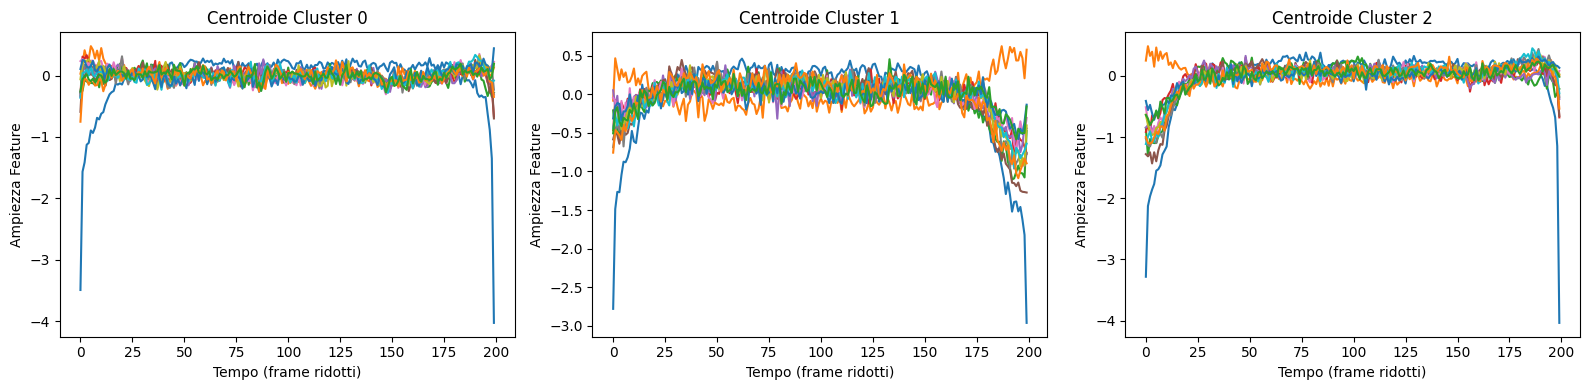

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
for i in range(k_scelto):
    plt.subplot(1, k_scelto, i + 1)
    
    cluster_data = X_clustering_scaled_resampled[cl_eu_unsup == i]
    
    # Calcoliamo il centroide medio per questo cluster
    centroid = cluster_data.mean(axis=0)
    
    plt.plot(centroid)
    plt.title(f"Centroide Cluster {i}")
    plt.xlabel("Tempo (frame ridotti)")
    plt.ylabel("Ampiezza Feature")

plt.tight_layout()
plt.show()

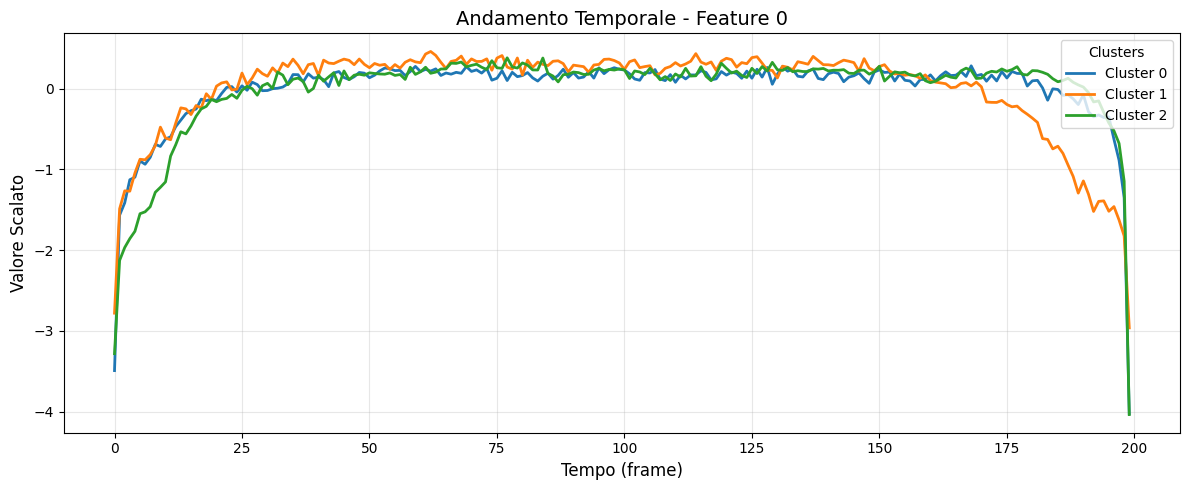

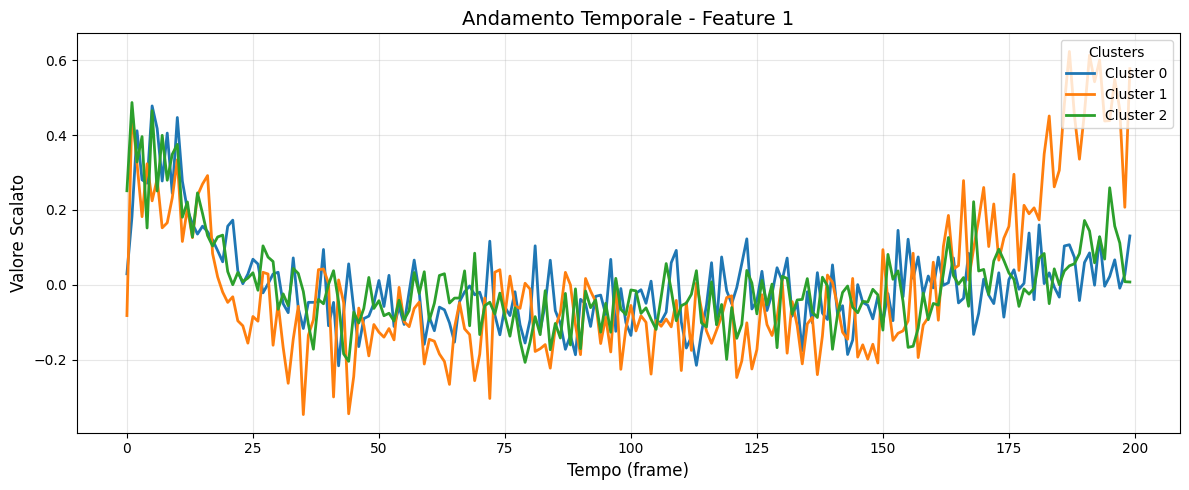

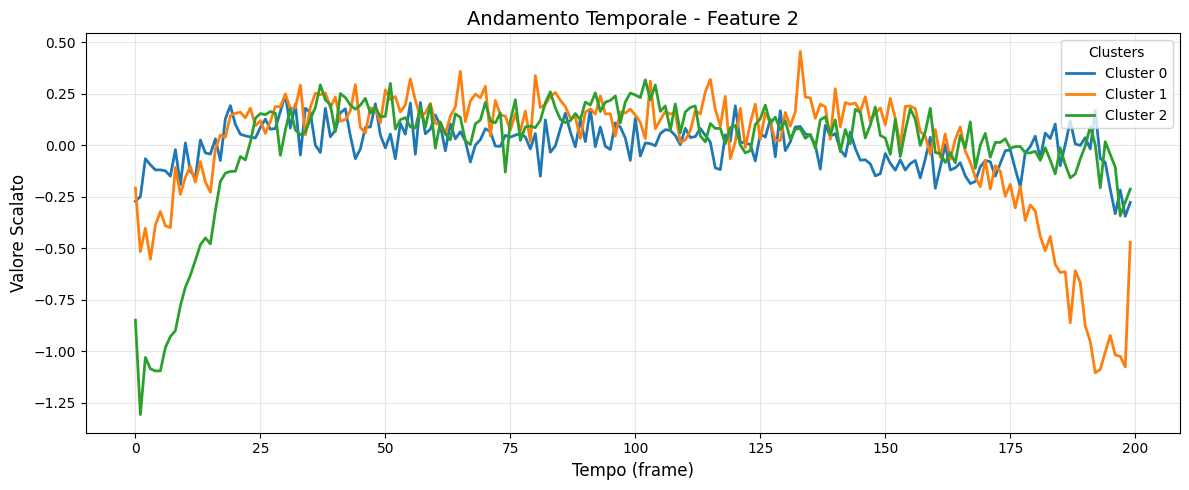

In [89]:
import matplotlib.pyplot as plt

feature_indices = [0, 1, 2]  # Le feature che vuoi analizzare
k_scelto = len(np.unique(cl_eu_unsup)) # Recupera il numero di cluster

for j in feature_indices:
    # Creiamo una nuova figura per ogni feature
    plt.figure(figsize=(12, 5))
    
    # Iteriamo su ogni cluster
    for i in range(k_scelto):
        # Estraiamo i dati del cluster i
        cluster_data = X_clustering_scaled_resampled[cl_eu_unsup == i]
        
        if len(cluster_data) > 0:
            # Calcoliamo il centroide (media dei brani nel cluster)
            # cluster_data è (n_brani, tempo, feature) -> mean(axis=0) è (tempo, feature)
            centroid = cluster_data.mean(axis=0)
            
            # Selezioniamo SOLO la feature j corrente
            plt.plot(centroid[:, j], label=f"Cluster {i}", linewidth=2)

    # Personalizzazione del grafico della feature j
    plt.title(f"Andamento Temporale - Feature {j}", fontsize=14)
    plt.xlabel("Tempo (frame)", fontsize=12)
    plt.ylabel("Valore Scalato", fontsize=12)
    plt.legend(loc='upper right', title="Clusters")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show() # Mostra il grafico della feature j prima di passare alla prossima

In [90]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo una copia per l'analisi: df_processed resta pulito
df_analysis = df_processed.copy()
df_analysis['cluster_eu_unsup'] = cl_eu_unsup  # Aggiungiamo i cluster solo alla copia

# 1. PCA: Appiattiamo X_scaled (454, 600, 60) -> (454, 3000)
X_flat = X_scaled.reshape(X_scaled.shape[0], -1)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_flat)

# Aggiungiamo le coordinate PCA alla copia per il plotting
df_analysis['pca_1'] = X_pca[:, 0]
df_analysis['pca_2'] = X_pca[:, 1]

df_analysis['pca_3'] = X_pca_3d[:, 2]

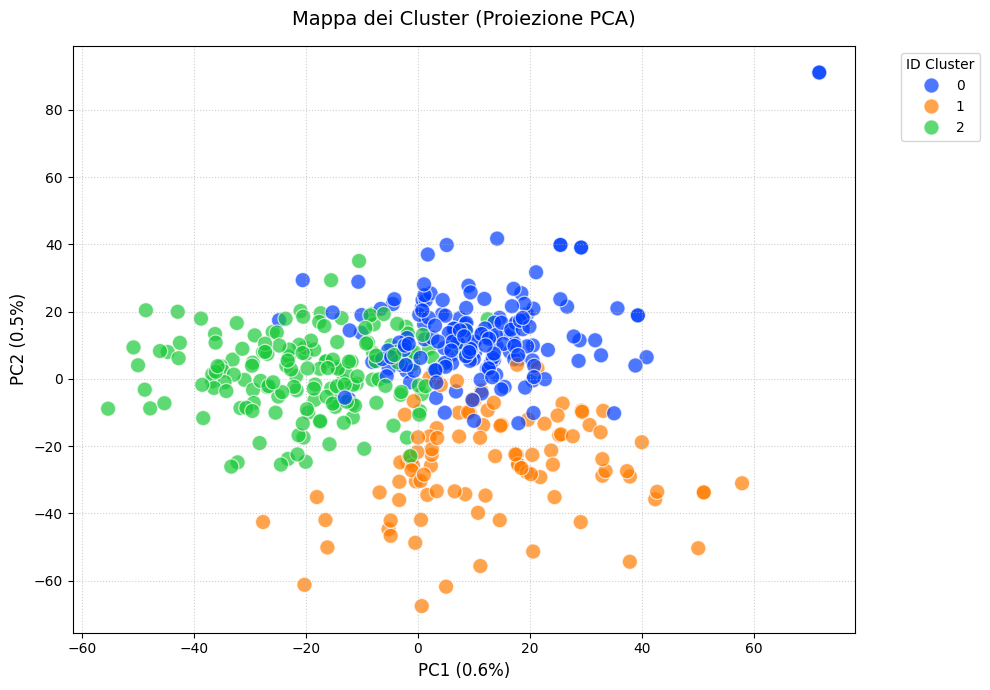

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# Usiamo una palette più accesa per distinguere bene i 3 cluster
# Palette consigliate: 'bright', 'tab10', 'Set1'
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_analysis, 
    x='pca_1', y='pca_2', 
    hue='cluster_eu_unsup', 
    palette='bright',    # Colori più netti e distinti
    s=120,               # Punti leggermente più grandi
    alpha=0.7,           # Trasparenza per gestire le sovrapposizioni
    edgecolor='w',       # Bordino bianco per far risaltare i punti vicini
    legend='full'
)

plt.title("Mappa dei Cluster (Proiezione PCA)", fontsize=14, pad=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=12)

# Miglioriamo la legenda
plt.legend(title='ID Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [92]:
import plotly.express as px

fig = px.scatter_3d(
    df_analysis, 
    x='pca_1', y='pca_2', 
    z='pca_3',
    color='cluster_eu_unsup',
    title='3D PCA Plot (Interactive)',
    opacity=0.7,
    size_max=5
)

# Update layout for a cleaner look
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

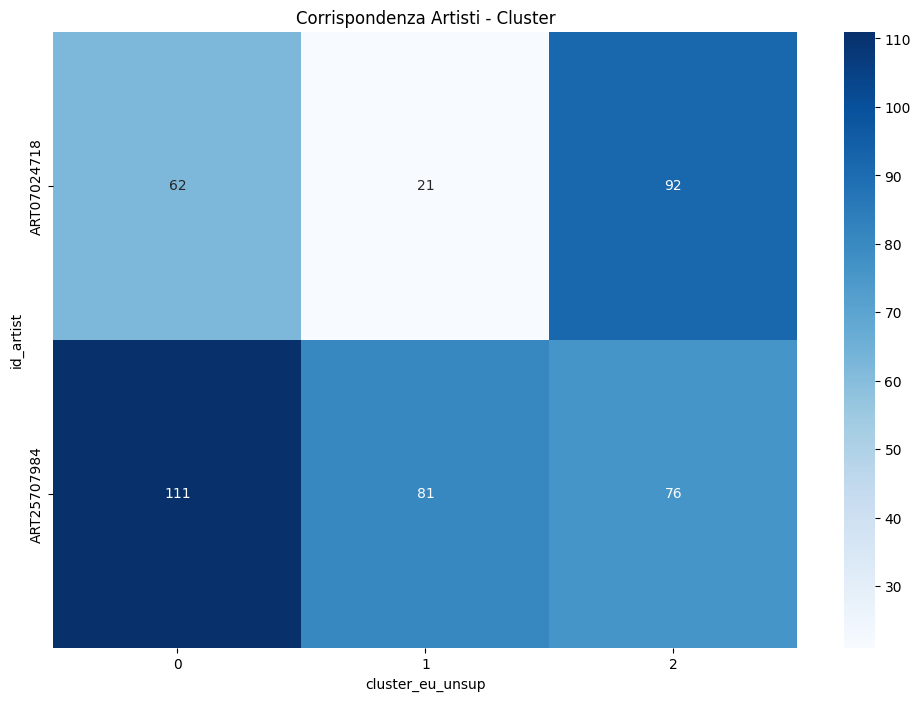

Cluster 0: L'artista più presente è 'ART25707984' (111 brani).
Cluster 1: L'artista più presente è 'ART25707984' (81 brani).
Cluster 2: L'artista più presente è 'ART07024718' (92 brani).


In [93]:
# Creiamo la tabella di contingenza (Artisti vs Cluster)
artist_ctab = pd.crosstab(df_analysis['id_artist'], df_analysis['cluster_eu_unsup'])

# Visualizzazione con Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(artist_ctab, annot=True, fmt='d', cmap="Blues")
plt.title("Corrispondenza Artisti - Cluster")
plt.show()

# Identifichiamo l'artista "simbolo" di ogni cluster
for c in sorted(df_analysis['cluster_eu_unsup'].unique()):
    top_art = artist_ctab[c].idxmax()
    count = artist_ctab[c].max()
    print(f"Cluster {c}: L'artista più presente è '{top_art}' ({count} brani).")

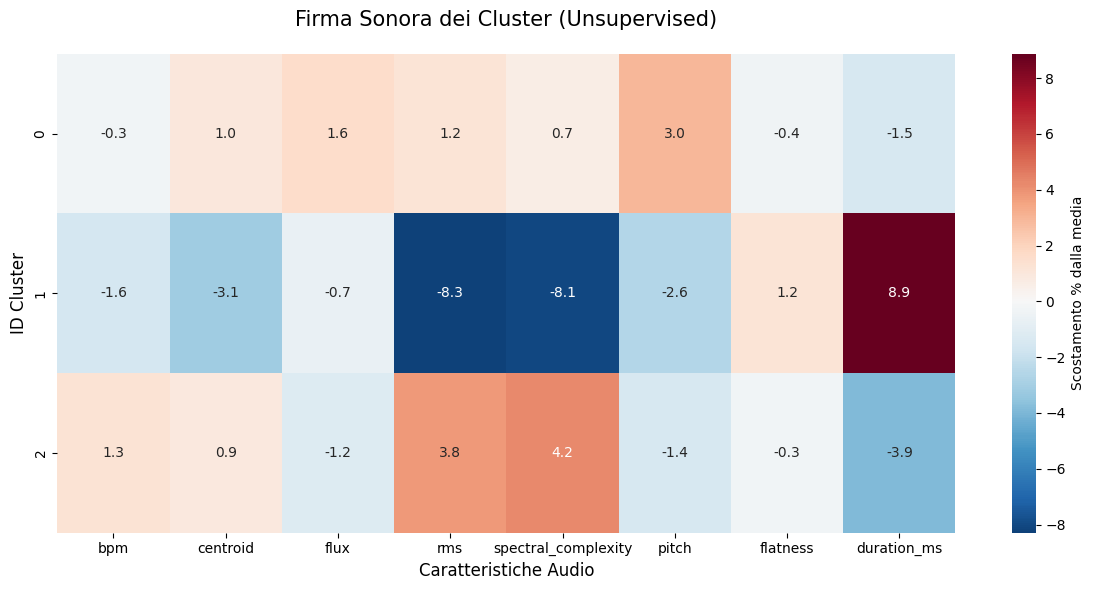

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepariamo i dati (usando la copia per non sporcare df_processed)
df_analysis = df_processed.copy()
df_analysis['cluster_eu_unsup'] = cl_eu_unsup

# 2. Calcoliamo lo scostamento percentuale rispetto alla media globale
cluster_means = df_analysis.groupby('cluster_eu_unsup')[AUDIO_COLS].mean()
global_means = df_analysis[AUDIO_COLS].mean()
relative_diff = (cluster_means / global_means - 1) * 100

# 3. Creazione della Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    relative_diff, 
    annot=True,              # Mostra i numeri dentro le celle
    fmt=".1f",               # Un decimale
    cmap="RdBu_r",           # Blu per valori bassi, Rosso per alti, Bianco per la media
    center=0,                # Il bianco rappresenta lo 0 (la media globale)
    cbar_kws={'label': 'Scostamento % dalla media'}
)

plt.title("Firma Sonora dei Cluster (Unsupervised)", fontsize=15, pad=20)
plt.ylabel("ID Cluster", fontsize=12)
plt.xlabel("Caratteristiche Audio", fontsize=12)
plt.tight_layout()
plt.show()

## General Motif

In [ ]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 0 to 453
Data columns (total 73 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       443 non-null    object 
 1   id_artist                      443 non-null    object 
 2   name_artist                    443 non-null    object 
 3   title                          443 non-null    object 
 4   featured_artists               443 non-null    object 
 5   language                       443 non-null    object 
 6   swear_IT                       443 non-null    int64  
 7   swear_EN                       443 non-null    int64  
 8   swear_IT_words                 443 non-null    object 
 9   swear_EN_words                 443 non-null    object 
 10  n_sentences                    443 non-null    float64
 11  n_tokens                       443 non-null    float64
 12  tokens_per_sent                443 non-null    float64


In [33]:
from stumpy import motifs
import numpy as np

m = 22
n_motifs_per_song = 3
motif_book = []      # Inizializzazione come lista
motif_metadata = []

print("Estrazione motif con cutoff dinamico e min_neighbors=1...")

for i in range(X_scaled.shape[0]):
    # Estrazione dati canzone e metadati
    song_data = X_scaled[i].astype(np.float64)
    artist = df_processed.iloc[i]['name_artist']
    song_title = df_processed.iloc[i]['title']
    track_id = df_processed.iloc[i]['track_id']
    
    # 1. Calcolo Matrix Profile
    song_mean = song_data.mean(axis=1)
    mp = stumpy.stump(song_mean, m=m)
    
    # 2. Calcolo Cutoff Dinamico
    # Sostituisci il calcolo del cutoff con questo:
    min_dist = np.amin(mp[:, 0])

    # Se min_dist è 0, usiamo una piccola costante, altrimenti raddoppiamo il minimo
    calc_cutoff = max(min_dist * 2.0, 0.1)
        
    # 3. Ricerca Motif
    # min_neighbors=1: il pattern deve ripetersi almeno una volta per essere un motif
    match_distances, match_indices = motifs(
        song_mean, 
        mp[:, 0], 
        max_motifs=n_motifs_per_song, 
        cutoff=calc_cutoff, 
        min_neighbors=1 
    )
    
    # 4. Popolamento del Book
    for idx_list in match_indices:
        if len(idx_list) > 0:
            best_idx = idx_list[0]
            
            # Segmento con tutte le feature (es. 60)
            motif_segment = song_data[best_idx : best_idx + m, :]
            
            # Aggiungiamo alla lista (appiattito per il clustering)
            motif_book.append(motif_segment.flatten())
            motif_metadata.append({
                'artist': artist,
                'song': song_title,
                'index': best_idx,
                'track_id': track_id
            })

# 5. Conversione finale in array NumPy
motif_book = np.array(motif_book)

print(f"✅ Book creato!")
print(f"   - Totale motif estratti: {len(motif_book)}")
print(f"   - Shape finale: {motif_book.shape}")

Estrazione motif con cutoff dinamico e min_neighbors=1...
✅ Book creato!
   - Totale motif estratti: 1326
   - Shape finale: (1326, 286)


## Euclidian based Clusters

In [ ]:
# Creiamo una lista per i cluster dei motif
motif_clusters = []

for meta in motif_metadata:
    # Troviamo la riga della canzone nel dataframe usando titolo e artista
    # (Uso .iloc[0] assumendo che la combinazione titolo-artista sia univoca)
    song_row = df_processed[(df_processed['title'] == meta['song']) & 
                           (df_processed['name_artist'] == meta['artist'])]
    
    if not song_row.empty:
        cluster_val = song_row['cluster_eu_unsup'].values[0]
        motif_clusters.append(cluster_val)
    else:
        motif_clusters.append(-1) # Valore di errore se non trova la canzone

motif_clusters = np.array(motif_clusters)

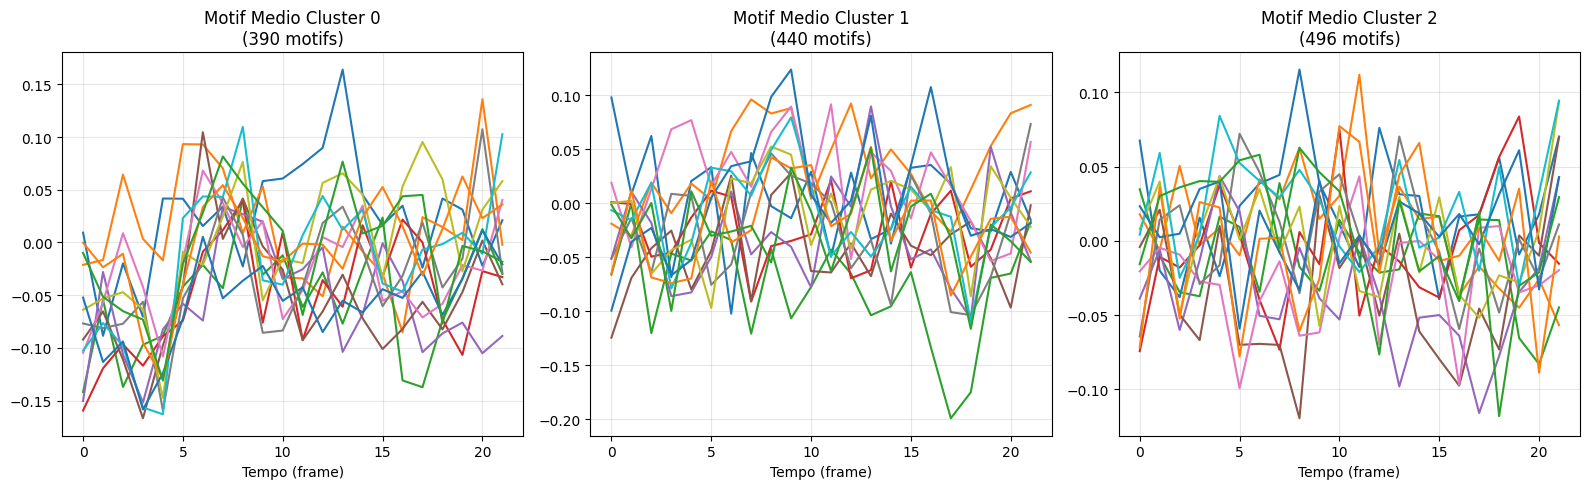

In [ ]:
import matplotlib.pyplot as plt

# Numero di cluster unici (escludendo eventuali -1)
unique_clusters = sorted([c for c in np.unique(motif_clusters) if c != -1])

plt.figure(figsize=(16, 5))

for i, cl_id in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i + 1)
    
    # Prendiamo i motif appartenenti a questo cluster
    cl_motif_indices = np.where(motif_clusters == cl_id)[0]
    specific_motifs = motif_book[cl_motif_indices]
    
    if len(specific_motifs) > 0:
        # Calcoliamo il motif medio del cluster
        # Torniamo alla forma (m, features) -> (15, 13)
        mean_motif = specific_motifs.mean(axis=0).reshape(m, -1)
        
        plt.plot(mean_motif)
        plt.title(f"Motif Medio Cluster {cl_id}\n({len(specific_motifs)} motifs)")
        plt.xlabel("Tempo (frame)")
        plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

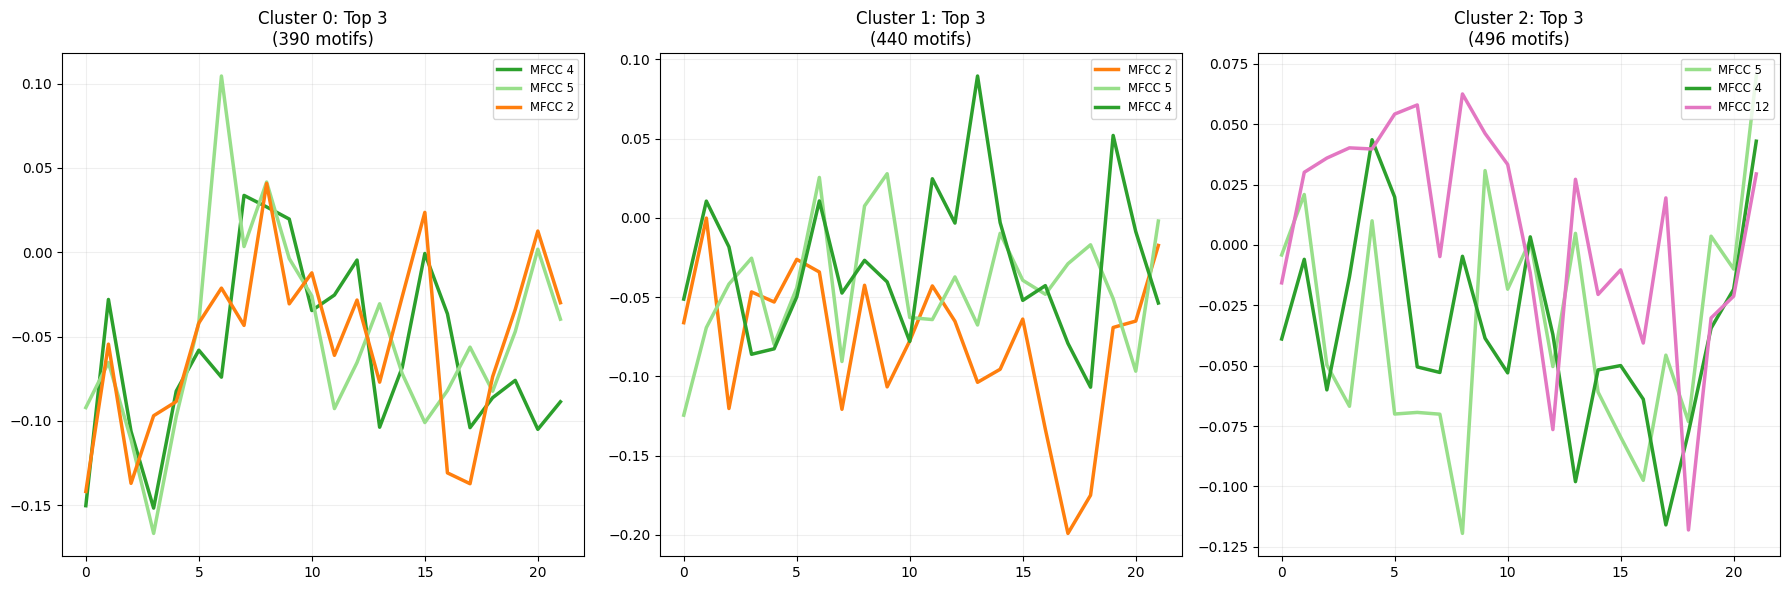

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definiamo una palette di colori fissa per le 13 feature
# 'tab20' è ottima perché ha 20 colori distinti, perfetti per i tuoi 13 MFCC
cmap = plt.get_cmap('tab20')

n_feat_to_show = 3 
m_frames = m
n_features = 13

plt.figure(figsize=(18, 6))

for i, cl_id in enumerate(unique_clusters):
    plt.subplot(1, len(unique_clusters), i + 1)
    
    cl_indices = np.where(motif_clusters == cl_id)[0]
    specific_motifs = motif_book[cl_indices].reshape(-1, m_frames, n_features)
    
    if len(specific_motifs) > 0:
        mean_motif = specific_motifs.mean(axis=0)
        importance = np.abs(mean_motif).mean(axis=0)
        top_indices = np.argsort(importance)[-n_feat_to_show:][::-1]
        
        for feat_idx in top_indices:
            # 2. Assegniamo il colore in base all'indice della feature, non all'ordine di plot
            plt.plot(mean_motif[:, feat_idx], 
                     label=f"MFCC {feat_idx}", 
                     color=cmap(feat_idx),  # <--- COLORE FISSO QUI
                     linewidth=2.5)
        
        plt.title(f"Cluster {cl_id}: Top {n_feat_to_show}\n({len(cl_indices)} motifs)")
        plt.legend(fontsize='small', loc='upper right')
        plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Spectrogram

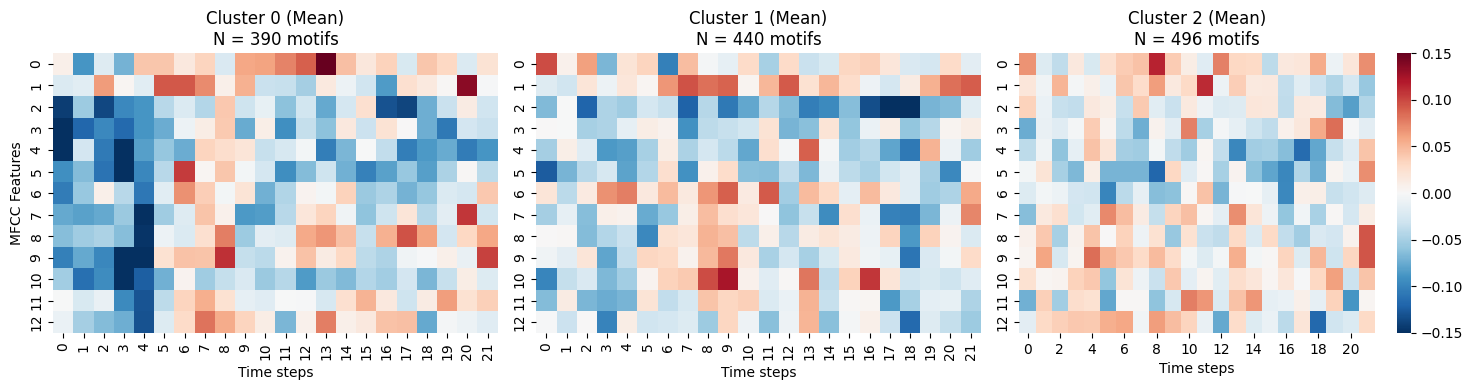

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Parametri presi dal tuo setup
m_frames = m
n_features = 13
unique_clusters = np.unique(motif_clusters)
unique_clusters = unique_clusters[unique_clusters != -1] # Escludiamo eventuali errori (-1)

# Calcolo del numero di colonne per il plot
n_clusters = len(unique_clusters)
plt.figure(figsize=(5 * n_clusters, 4)) # Si adatta dinamicamente al numero di cluster

for i, cl_id in enumerate(unique_clusters):
    ax = plt.subplot(1, n_clusters, i + 1)
    
    # 1. Estraiamo i motif del cluster e calcoliamo la media
    cl_indices = np.where(motif_clusters == cl_id)[0]
    # Reshape: (numero_motif, tempo, feature)
    specific_motifs = motif_book[cl_indices].reshape(-1, m_frames, n_features)
    
    if len(specific_motifs) > 0:
        # Calcoliamo il motif "prototipo" del cluster:
        # $$\bar{M} = \frac{1}{N} \sum_{i=1}^{N} Motif_i$$
        mean_motif = specific_motifs.mean(axis=0)
        
        # 2. Plotting come Heatmap
        # Trasponiamo per avere le Feature (13) sulle Y e il Tempo (15) sulle X
        sns.heatmap(mean_motif.T, 
                    ax=ax, 
                    cmap='RdBu_r', 
                    cbar=(i == n_clusters - 1), # Mostra la barra solo nell'ultimo plot
                    vmin=-0.15, vmax=0.15) # Opzionale: fissa il range se i dati sono scalati
        
        ax.set_title(f"Cluster {cl_id} (Mean)\nN = {len(cl_indices)} motifs")
        ax.set_xlabel("Time steps")
        if i == 0:
            ax.set_ylabel("MFCC Features")
        else:
            ax.set_ylabel("")

plt.tight_layout()
plt.show()

## General Anomalies

In [ ]:
import numpy as np
import stumpy

m = 86
n_anomalies_per_song = 3
anomaly_book = []
anomaly_metadata = []

print(f"Estrazione di {n_anomalies_per_song} anomalie per brano (manual masking)...")

for i in range(X_scaled.shape[0]):
    song_data = X_scaled[i].astype(np.float64)
    artist = df_analysis.iloc[i]['name_artist']
    song_title = df_analysis.iloc[i]['title']
    
    # 1. Calcolo Matrix Profile
    song_mean = song_data.mean(axis=1)
    mp = stumpy.stump(song_mean, m=m)
    
    # Copiamo le distanze per poterle modificare (mascherare)
    distances = mp[:, 0].copy()
    
    for _ in range(n_anomalies_per_song):
        # 2. Trova l'indice del valore massimo (l'anomalia)
        d_idx = np.argmax(distances)
        d_dist = distances[d_idx]
        
        # 3. Salvataggio nel book
        anomaly_segment = song_data[d_idx : d_idx + m, :]
        anomaly_book.append(anomaly_segment.flatten())
        anomaly_metadata.append({
            'artist': artist,
            'song': song_title,
            'index': d_idx,
            'distance': d_dist
        })
        
        # 4. MASCHERAMENTO: azzeriamo l'area intorno all'anomalia trovata 
        # per non riprendere lo stesso punto (raggio di esclusione = m)
        start = max(0, d_idx - m)
        end = min(len(distances), d_idx + m)
        distances[start:end] = -1.0 # Usiamo -1 perché le distanze reali sono >= 0

anomaly_book = np.array(anomaly_book)
print(f"✅ Fatto! Totale anomalie estratte: {len(anomaly_book)}")

Estrazione di 3 anomalie per brano (manual masking)...
✅ Fatto! Totale anomalie estratte: 1344


In [ ]:
# Creiamo la lista dei cluster per le anomalie
anomaly_clusters = []

for meta in anomaly_metadata:
    # Troviamo il cluster della canzone corrispondente nel dataframe
    song_row = df_analysis[(df_analysis['title'] == meta['song']) & 
                           (df_analysis['name_artist'] == meta['artist'])]
    
    if not song_row.empty:
        cluster_val = song_row['cluster_eu_unsup'].values[0]
        anomaly_clusters.append(cluster_val)
    else:
        anomaly_clusters.append(-1)

anomaly_clusters = np.array(anomaly_clusters)

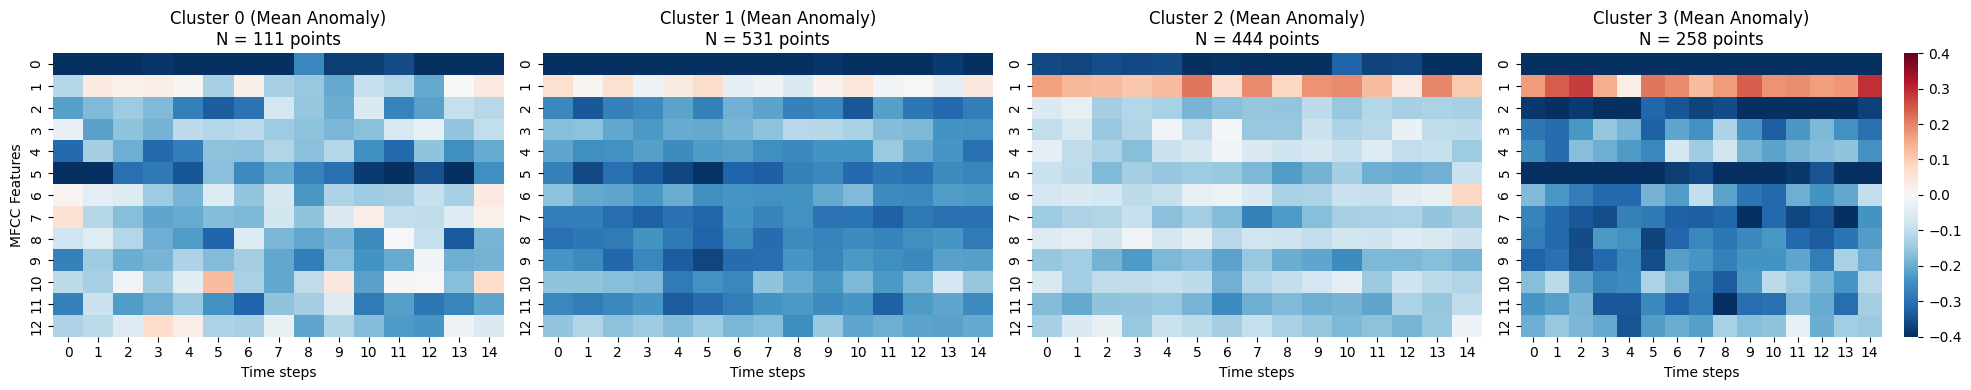

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Parametri del segnale
m_frames = 86
n_features = 13
unique_clusters = np.unique(anomaly_clusters)
unique_clusters = unique_clusters[unique_clusters != -1] # Escludiamo errori

n_clusters = len(unique_clusters)
plt.figure(figsize=(5 * n_clusters, 4))

for i, cl_id in enumerate(unique_clusters):
    ax = plt.subplot(1, n_clusters, i + 1)
    
    # 1. Filtriamo le anomalie appartenenti a questo cluster di canzoni
    cl_indices = np.where(anomaly_clusters == cl_id)[0]
    specific_anomalies = anomaly_book[cl_indices].reshape(-1, m_frames, n_features)
    
    if len(specific_anomalies) > 0:
        # 2. Calcolo dell'anomalia media del cluster
        mean_anomaly = specific_anomalies.mean(axis=0)
        
        # 3. Plotting Heatmap
        sns.heatmap(mean_anomaly.T, 
                    ax=ax, 
                    cmap='RdBu_r', # 'rocket' è ottimo per le anomalie (toni caldi/scuri)
                    cbar=(i == n_clusters - 1),
                    vmin=-0.4, vmax=0.4) # Regola in base al tuo scaling
        
        ax.set_title(f"Cluster {cl_id} (Mean Anomaly)\nN = {len(cl_indices)} points")
        ax.set_xlabel("Time steps")
        if i == 0:
            ax.set_ylabel("MFCC Features")
        else:
            ax.set_ylabel("")

plt.tight_layout()
plt.show()

## MOTIF second version


Calcolo del numero ottimale di cluster con TimeSeriesKMeans...
k=2 | Inertia: 280.52
k=2 | Silhouette Score: 0.03
k=3 | Inertia: 275.33
k=3 | Silhouette Score: 0.02
k=4 | Inertia: 272.50
k=4 | Silhouette Score: 0.02
k=5 | Inertia: 269.92
k=5 | Silhouette Score: 0.02
k=6 | Inertia: 267.88
k=6 | Silhouette Score: 0.02
k=7 | Inertia: 266.58
k=7 | Silhouette Score: 0.01


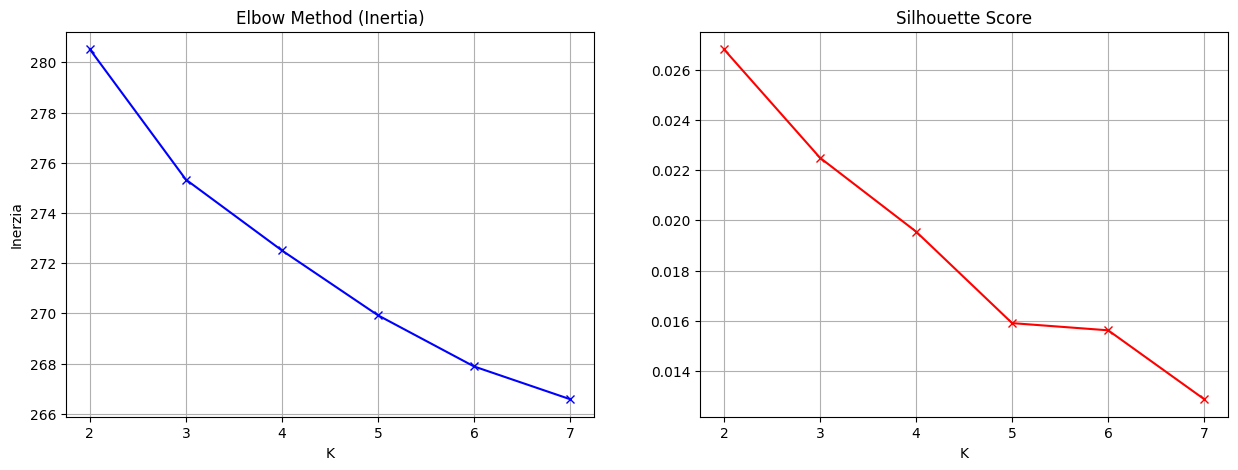

In [ ]:
# Range di cluster da testare
K_range = range(2, 8)
inertias = []
silhouette_avg = []

print("Calcolo del numero ottimale di cluster con TimeSeriesKMeans...")

for k in K_range:

    model = TimeSeriesKMeans(n_clusters=k, 
                             metric="euclidean",      
                             max_iter=10, 
                             random_state=42)
    
    # Non serve appiattire i dati! Passa pure (N, 40, 13)
    labels = model.fit_predict(motif_book)
    
    # Inerzia
    inertias.append(model.inertia_)

    print(f"k={k} | Inertia: {model.inertia_:.2f}")
    
    try:
        score = silhouette_score(motif_book, labels, metric="euclidean")
        silhouette_avg.append(score)
        print(f"k={k} | Silhouette Score: {silhouette_avg[-1]:.2f}")
    except:
        silhouette_avg.append(np.nan)

   

# --- Visualizzazione ---
plt.figure(figsize=(15, 5))

# Plot Elbow Method
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bx-')
plt.title('Elbow Method (Inertia)')
plt.ylabel('Inerzia')
plt.xlabel('K')
plt.grid(True)

# Plot Silhouette
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_avg, 'rx-')
plt.title('Silhouette Score')
plt.xlabel('K')
plt.grid(True)

plt.show()

In [ ]:
k= 3

model = TimeSeriesKMeans(n_clusters=k, 
                            metric="euclidean",      
                            max_iter=10, 
                            random_state=42)

# Non serve appiattire i dati! Passa pure (N, 40, 13)
labels = model.fit_predict(motif_book)




   

NameError: name 'inertias' is not defined

Running PCA on shape: (1326, 286)
PCA Variance Explained (2D): 7.96%


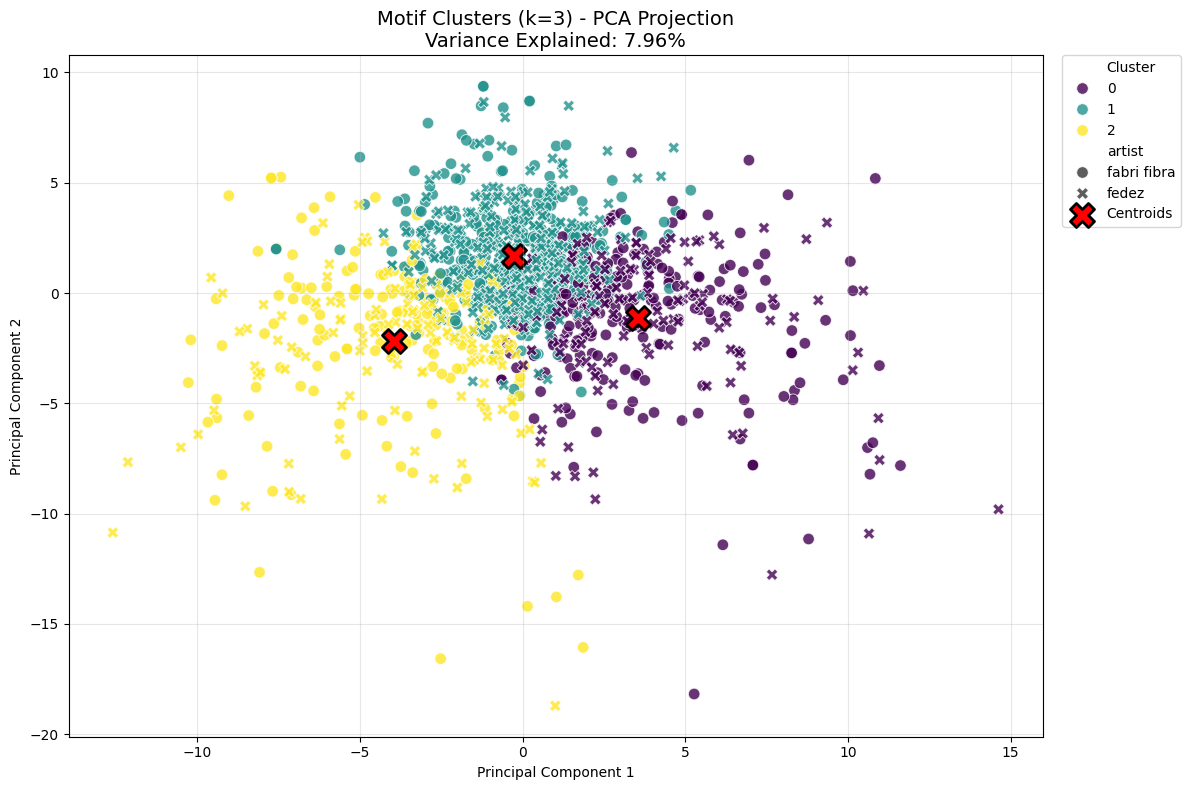

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- 1. Data Preparation ---
# Convert metadata list to a Pandas DataFrame
df_viz = pd.DataFrame(motif_metadata)

# Add the cluster labels you just computed (k=3)
df_viz['Cluster'] = labels

# --- 2. Run PCA ---
# motif_book is already flattened (N_motifs, m * n_features) from your extraction step
print(f"Running PCA on shape: {motif_book.shape}")

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(motif_book)

# Add PCA coordinates to the DataFrame
df_viz['PCA_1'] = pca_result[:, 0]
df_viz['PCA_2'] = pca_result[:, 1]

# Calculate explained variance (to know how much info the plot shows)
var_explained = pca.explained_variance_ratio_.sum() * 100
print(f"PCA Variance Explained (2D): {var_explained:.2f}%")

# --- 3. Visualization ---
plt.figure(figsize=(12, 8))

# Scatterplot
# Hue (Color) = Cluster (The 3 groups found by KMeans)
# Style (Shape) = Artist (To see if Fedez and Fibra separate)
sns.scatterplot(
    data=df_viz,
    x='PCA_1',
    y='PCA_2',
    hue='Cluster',        
    style='artist',       
    palette='viridis',     
    s=70,                 # Dot size
    alpha=0.8,            # Transparency
    edgecolor='w'         # White border around dots for clarity
)

# Plot Centroids (Optional but helpful)
# We need to project the KMeans centroids into the same PCA space
# --- CODICE CORRETTO ---

# 1. Appiattiamo i centroidi da (3, 40, 13) a (3, 520)
centroids_flat = model.cluster_centers_.reshape(model.cluster_centers_.shape[0], -1)

# 2. Ora la PCA accetta l'input
centroids_pca = pca.transform(centroids_flat)

# 3. Plot (rimane uguale)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            s=300, c='red', marker='X', label='Centroids', edgecolors='black', linewidth=2)


plt.title(f'Motif Clusters (k=3) - PCA Projection\nVariance Explained: {var_explained:.2f}%', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

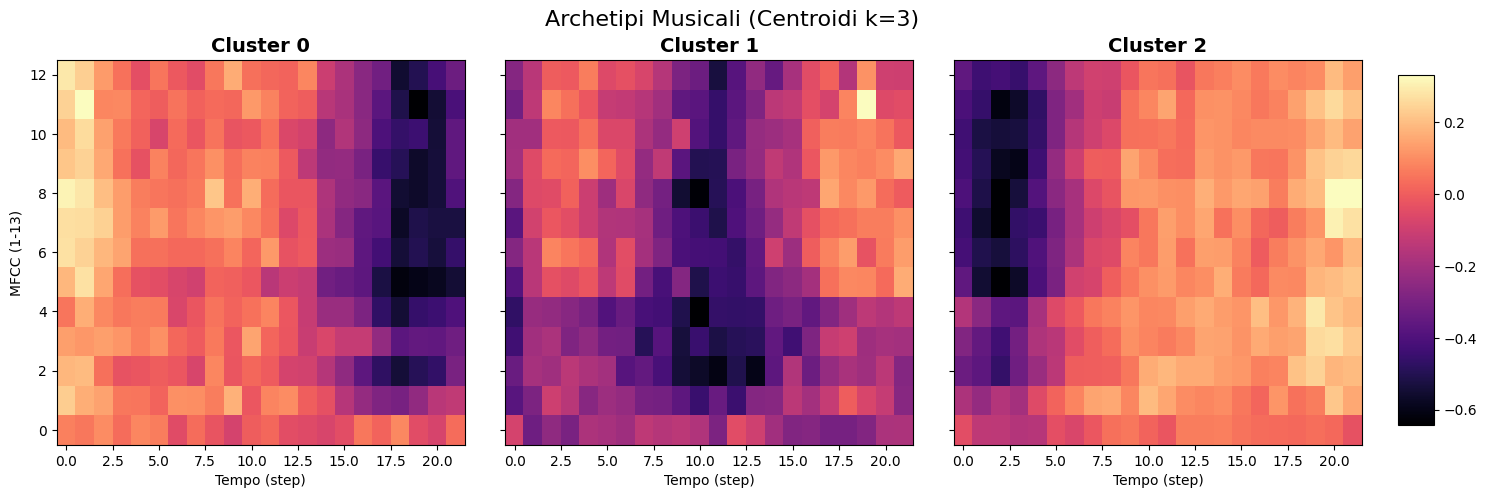

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Parametri originali
m = 22             
n_features = 13    

# 1. Recupera i centroidi appiattiti
centroids_flat = model.cluster_centers_.squeeze() 

# 2. Configura il plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f'Archetipi Musicali (Centroidi k=3)', fontsize=16)

# 3. Reshape e Plot
images = [] # Salviamo gli oggetti 'im' per la colorbar
for i, ax in enumerate(axes):
    min_neighbors=1 
    # A. Prendi il centroide piatto
    center_flat = centroids_flat[i]
    
    # B. RESHAPE: Da (286,) a (22, 13)
    center_reshaped = center_flat.reshape(m, n_features) 
    
    # C. Trasponi per (13, 22) -> (Features, Tempo)
    centroid_spectrogram = center_reshaped.T
    
    # D. Plot
    im = ax.imshow(centroid_spectrogram, 
                   aspect='auto', 
                   origin='lower', 
                   cmap='magma',     
                   interpolation='nearest')
    images.append(im)
    
    ax.set_title(f'Cluster {i}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Tempo (step)')
    if i == 0:
        ax.set_ylabel('MFCC (1-13)')

# --- LA FIX PER L'OVERLAP ---
# 1. Lasciamo spazio a destra del grafico (riduciamo i grafici all'85% della larghezza)
plt.subplots_adjust(right=0.85, wspace=0.1) 

# 2. Creiamo un asse specifico per la colorbar [left, bottom, width, height]
#    0.87 = inizia all'87% della larghezza (nello spazio vuoto creato sopra)
#    0.15 = altezza dal fondo
#    0.02 = larghezza della barra
#    0.7  = altezza della barra
cax = fig.add_axes([0.87, 0.15, 0.02, 0.7]) 

# 3. Disegniamo la colorbar in quell'asse specifico
cbar = fig.colorbar(images[0], cax=cax)

In [37]:
# 1. Raggruppa per Canzone e conta i cluster UNICI
# df_viz è il DataFrame che abbiamo creato prima con 'song', 'artist', 'Cluster'
song_diversity = df_viz.groupby(['song', 'artist'])['Cluster'].nunique().reset_index()

# Rinominiamo la colonna per chiarezza
song_diversity.rename(columns={'Cluster': 'Unique_Clusters'}, inplace=True)

# 2. Mappiamo i valori numerici (1, 2, 3) a etichette leggibili
diversity_map = {
    1: 'Monotona (Tutti uguali)',
    2: 'Mista (2 tipi diversi)',
    3: 'Ricca (Tutti diversi)'
}
song_diversity['Category'] = song_diversity['Unique_Clusters'].map(diversity_map)

# Mostriamo un'anteprima
print("Esempi di canzoni e la loro diversità:")
print(song_diversity.head())

Esempi di canzoni e la loro diversità:
         song       artist  Unique_Clusters                 Category
0         + -  fabri fibra                2   Mista (2 tipi diversi)
1   21 Grammi        fedez                2   Mista (2 tipi diversi)
2    3 Parole  fabri fibra                1  Monotona (Tutti uguali)
3  3 di notte        fedez                2   Mista (2 tipi diversi)
4        6791  fabri fibra                3    Ricca (Tutti diversi)


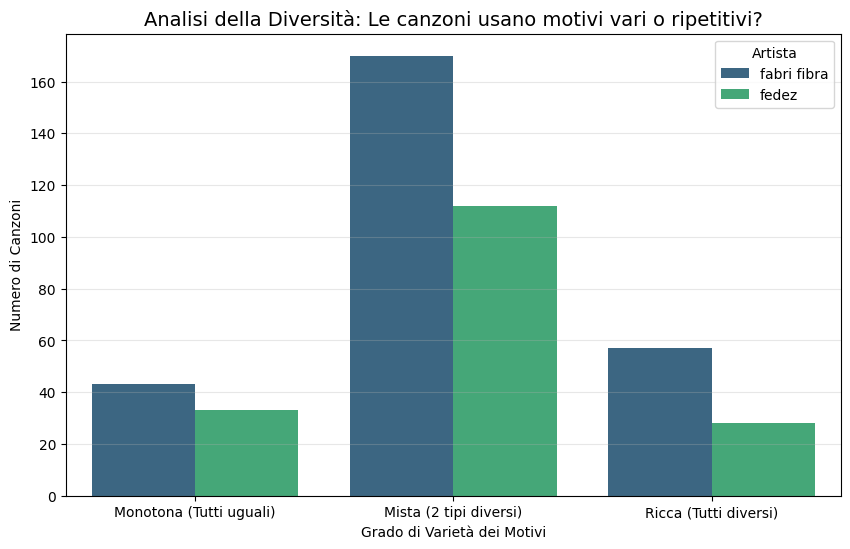

In [38]:
plt.figure(figsize=(10, 6))

# Countplot: Conta quante canzoni cadono in ogni categoria, divise per artista
sns.countplot(
    data=song_diversity,
    x='Category',
    hue='artist',
    order=['Monotona (Tutti uguali)', 'Mista (2 tipi diversi)', 'Ricca (Tutti diversi)'],
    palette='viridis'
)

plt.title("Analisi della Diversità: Le canzoni usano motivi vari o ripetitivi?", fontsize=14)
plt.ylabel("Numero di Canzoni")
plt.xlabel("Grado di Varietà dei Motivi")
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Artista')
plt.show()

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperiamo i Cluster delle Canzoni dal df principale
# Assumiamo che 'title' sia la chiave di giunzione e 'cluster_eu_unsup' sia l'ID del cluster
song_clusters_info = df_analysis[['title', 'cluster_eu_unsup']].rename(columns={'title': 'song'})

# 2. Uniamo con il dataframe della diversità creato prima
merged_diversity = song_diversity.merge(song_clusters_info, on='song', how='inner')

print(f"Merge completato. Righe totali: {len(merged_diversity)}")

Merge completato. Righe totali: 440


In [96]:
# 1. Creiamo una tabella pivot: Righe=Cluster Canzoni, Colonne=Categoria Diversità
diversity_matrix = pd.crosstab(
    merged_diversity['cluster_eu_unsup'], 
    merged_diversity['Category']
)

# 2. Riordiniamo le colonne per logica (dal semplice al complesso)
order = ['Monotona (Tutti uguali)', 'Mista (2 tipi diversi)', 'Ricca (Tutti diversi)']
diversity_matrix = diversity_matrix[order]

# 3. Normalizziamo in Percentuale (così i cluster grandi non schiacciano quelli piccoli)
diversity_pct = diversity_matrix.div(diversity_matrix.sum(axis=1), axis=0) * 100

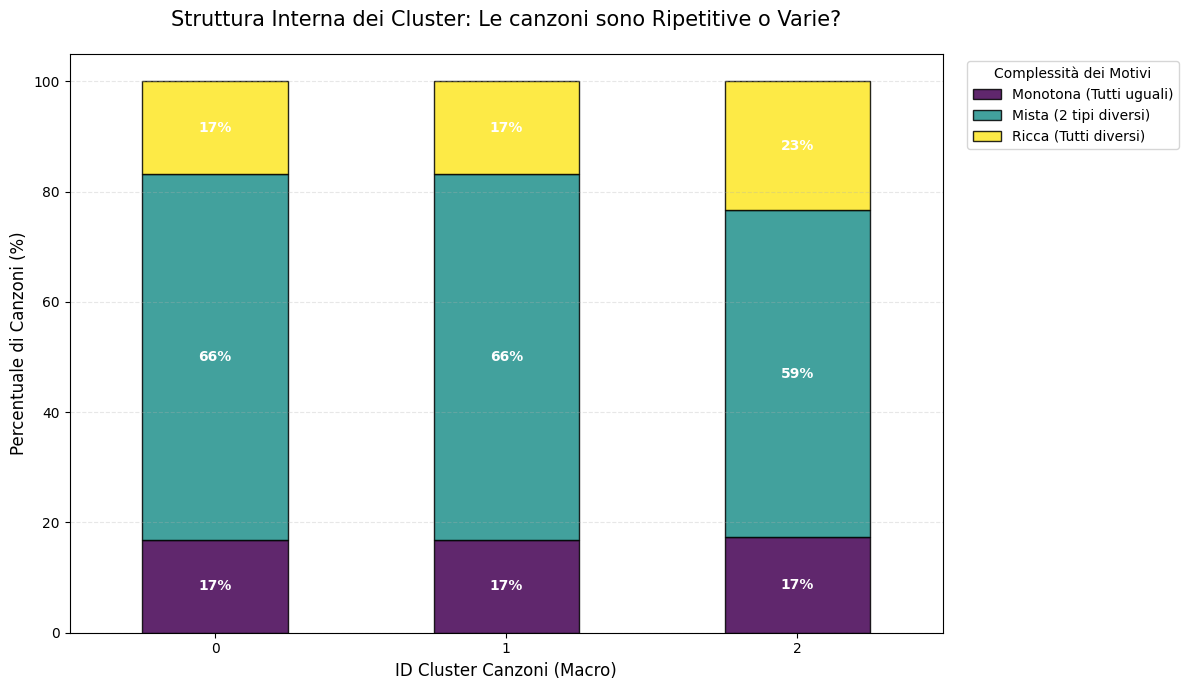

In [97]:
# Setup del grafico
ax = diversity_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    colormap='viridis', # Usa 'coolwarm' o 'viridis'
    edgecolor='black',
    alpha=0.85
)

# Abbellimenti
plt.title("Struttura Interna dei Cluster: Le canzoni sono Ripetitive o Varie?", fontsize=15, pad=20)
plt.ylabel("Percentuale di Canzoni (%)", fontsize=12)
plt.xlabel("ID Cluster Canzoni (Macro)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Complessità dei Motivi', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Aggiungiamo le etichette percentuali dentro le barre
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## ANOMALY version 2 
